# 02. Feature Engineering и эксперименты кластеризации

Во втором ноутбуке продолжаем работать после EDA и базовой предобработки, выполненных в первом ноутбуке. На этапе EDA было показано, что сигналы имеют фиксированную длину 500 отсчётов, основной импульс направлен вниз, пик расположен в узкой области около 150-го временного отсчёта, а первые 50 отсчётов можно использовать для оценки базовой линии.

Цель этого ноутбука — построить несколько вариантов признакового описания сигналов, сравнить разные алгоритмы кластеризации и выбрать финальный подход для submission.

## Логика исследования

В задаче нет обучающих меток, поэтому качество кластеризации сначала оценивается косвенно: по внутренним метрикам, размерам кластеров, профилям кластеров и физической интерпретации признаков. Kaggle submission использовался только для наиболее перспективных вариантов, а не для каждого промежуточного запуска.

В ноутбуке разделяются две части работы:

1. **Базовая подготовка сигнала**, общая для всех экспериментов:
   - отделение служебных metadata-колонок от временных отсчётов;
   - расчёт индивидуальной базовой линии по первым 50 отсчётам;
   - инверсия сигнала относительно baseline;
   - формирование двух представлений сигнала: `signals_inverted` и `signals_positive`.

2. **Варианты признакового описания**, которые сравниваются экспериментально:
   - энергетические признаки: амплитуда, площадь, преобразования площади;
   - геометрические признаки формы: отношение амплитуды к площади, угол, эксцесс;
   - PSD-признаки, отражающие вклад хвостовой части сигнала;
   - признаки формы хвоста после максимума с PCA.

Такой ход исследования связан с физикой задачи: для сцинтилляционных сигналов важны не только амплитуда и площадь, но и форма спада после пика. В теоретическом описании задачи отдельно отмечено, что различия между сигналами проявляются во времени высвечивания и в распределении площади между коротким и длинным участками сигнала. Поэтому финальные эксперименты отдельно проверяют tail-подход, основанный на раннем хвосте после максимума.

## План экспериментов

1. Сформировать физико-интерпретируемые признаки.
2. Проанализировать распределения, scatter `volume`–`amplitude` и корреляции.
3. Сравнить KMeans, GMM и AgglomerativeClustering на разных наборах признаков.
4. Проверить, не делят ли лучшие по внутренним метрикам модели сигналы только по мощности.
5. Перейти к признакам хвоста после пика и проверить несколько вариантов tail-подхода.
6. Зафиксировать Kaggle score только для выбранных перспективных вариантов.
7. Выбрать финальный компактный пайплайн для третьего ноутбука.

## 1. Импорт библиотек

## 1. Импорт библиотек

In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
warnings.filterwarnings("ignore")

## 2. Константы и пути

In [ ]:
RANDOM_STATE = 42
BASELINE_WINDOW = 50

PROJECT_DIR = Path(".")
DATA_DIR = PROJECT_DIR / "data"

DATA_PATH = DATA_DIR / "Run200_Wave_0_1.txt"

## 3.Чтение исходного txt-файла

In [ ]:
# Проверка папки data и исходного файла

if DATA_DIR.exists():
    print("Папка data уже существует.")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print("Папка data не найдена, поэтому была создана.")

print()
print("Путь к папке data:")
print(DATA_DIR.resolve())

print()
print("Файлы в папке data:")
data_files = sorted(DATA_DIR.glob("*"))

if data_files:
    for file_path in data_files:
        print(f"- {file_path.name}")
else:
    print("Папка data пока пустая.")

print()
print("Ожидаемый путь к исходному файлу:")
print(DATA_PATH)

print()
print(f"Файл найден: {DATA_PATH.exists()}")

Папка data не найдена, поэтому была создана.

Путь к папке data:
/content/data

Файлы в папке data:
Папка data пока пустая.

Ожидаемый путь к исходному файлу:
data/Run200_Wave_0_1.txt

Файл найден: False


In [ ]:
raw_data = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
)

metadata = raw_data.iloc[:, :4].copy()
signals = raw_data.iloc[:, 4:].copy()

metadata.columns = ["meta_0", "meta_1", "meta_2", "signal_length"]
signals.columns = [f"t_{i}" for i in range(signals.shape[1])]

print(f"Размер исходной таблицы: {raw_data.shape}")
print(f"Размер metadata: {metadata.shape}")
print(f"Размер signals: {signals.shape}")

Размер исходной таблицы: (23479, 504)
Размер metadata: (23479, 4)
Размер signals: (23479, 500)


## 4. Базовая предобработка, общая для всех экспериментов

In [ ]:
signals_np = signals.to_numpy(dtype=float)

baselines = np.mean(
    signals_np[:, :BASELINE_WINDOW],
    axis=1,
    keepdims=True,
)

signals_inverted = baselines - signals_np
signals_positive = np.clip(
    signals_inverted,
    a_min=0,
    a_max=None,
)

print(f"Размер signals_np: {signals_np.shape}")
print(f"Размер baselines: {baselines.shape}")
print(f"Размер signals_inverted: {signals_inverted.shape}")
print(f"Размер signals_positive: {signals_positive.shape}")

print()
print("Диапазон значений после инверсии:")
print(f"Минимум: {signals_inverted.min():.2f}")
print(f"Максимум: {signals_inverted.max():.2f}")

print()
print("Диапазон значений после clip:")
print(f"Минимум: {signals_positive.min():.2f}")
print(f"Максимум: {signals_positive.max():.2f}")

Размер signals_np: (23479, 500)
Размер baselines: (23479, 1)
Размер signals_inverted: (23479, 500)
Размер signals_positive: (23479, 500)

Диапазон значений после инверсии:
Минимум: -15.60
Максимум: 14824.84

Диапазон значений после clip:
Минимум: 0.00
Максимум: 14824.84


### Вывод по базовой предобработке

Была выполнена базовая предобработка, общая для всех дальнейших экспериментов: для каждого сигнала рассчитана индивидуальная базовая линия по первым 50 отсчётам, после чего сигнал был инвертирован относительно этого уровня.

Размер матрицы сигналов сохранился: `23479 × 500`. После инверсии основной импульс направлен вверх, а значения около нуля соответствуют базовой линии и шуму.

Дополнительно была создана версия `signals_positive`, где отрицательные значения после baseline-коррекции заменены на ноль. Она будет использоваться для расчёта площадей и энергетических признаков, чтобы отрицательные шумовые колебания не искажали интегральные характеристики импульса.

## 5.Feature Engineering: физико-интерпретируемые признаки
**5.1 Базовые энергетические признаки**

In [ ]:
amplitudes = np.max(signals_positive, axis=1)
peak_indices = np.argmax(signals_positive, axis=1)

volumes = np.sum(signals_positive, axis=1)
safe_volumes = np.where(volumes <= 0, 1e-5, volumes)

sqrt_volumes = np.sqrt(safe_volumes)
log_volumes = np.log1p(safe_volumes)
area_to_amplitude = safe_volumes / np.where(amplitudes <= 0, 1e-5, amplitudes)

energy_features = pd.DataFrame(
    {
        "amplitude": amplitudes,
        "peak_index": peak_indices,
        "volume": volumes,
        "sqrt_volume": sqrt_volumes,
        "log_volume": log_volumes,
        "area_to_amplitude": area_to_amplitude,
    }
)

print(f"Размер таблицы энергетических признаков: {energy_features.shape}")
display(energy_features.describe().T)
display(energy_features.head())

Размер таблицы энергетических признаков: (23479, 6)


,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.104716,2389.300501,104.300000,308.160000,812.540000,2315.050000,14824.840000
peak_index,23479.0,149.628604,2.489996,145.000000,149.000000,150.000000,151.000000,472.000000
volume,23479.0,13517.662262,16026.495292,1043.360000,2888.020000,6638.200000,17591.250000,113281.080000
sqrt_volume,23479.0,100.599553,58.288394,32.301084,53.740301,81.475150,132.632010,336.572548
log_volume,23479.0,8.916916,1.091950,6.951160,7.968673,8.800747,9.775214,11.637636
area_to_amplitude,23479.0,8.677474,1.964870,5.476231,6.889547,8.442981,9.886165,19.364007


,amplitude,peak_index,volume,sqrt_volume,log_volume,area_to_amplitude
0,530.48,149,5107.88,71.469434,8.538735,9.628789
1,1901.48,150,12659.20,112.513110,9.446218,6.657551
2,2557.90,151,17257.70,131.368565,9.756072,6.746824
3,564.56,149,4954.04,70.384942,8.508161,8.775046
4,1793.60,150,12067.60,109.852629,9.398362,6.728145


### Вывод по базовым энергетическим признакам

Были рассчитаны базовые энергетические признаки сигнала: амплитуда, положение пика, площадь положительной части импульса, а также преобразования площади через квадратный корень и логарифм.

Амплитуда и площадь имеют широкий диапазон значений, что отражает различную интенсивность зарегистрированных событий. При этом `peak_index` у большинства сигналов находится около 149–151-го отсчёта, что согласуется с выводами первого ноутбука о синхронизации импульсов.

Признаки `sqrt_volume` и `log_volume` добавлены для нелинейного масштабирования площади: они уменьшают влияние очень больших импульсов и могут быть полезны для моделей кластеризации. Признак `area_to_amplitude` описывает соотношение площади и высоты импульса, то есть косвенно отражает “ширину” или растянутость сигнала.

**5.2 Геометрические признаки формы**

In [ ]:
# Расчёт геометрических признаков формы импульса

ratio = amplitudes / safe_volumes
angles = np.arctan(ratio)
kurt_values = pd.DataFrame(signals_positive).kurt(axis=1).to_numpy()

geometry_features = pd.DataFrame(
    {
        "ratio": ratio,
        "angle": angles,
        "kurtosis": kurt_values,
    }
)

print(f"Размер таблицы геометрических признаков: {geometry_features.shape}")
display(geometry_features.describe().T)
display(geometry_features.head())

Размер таблицы геометрических признаков: (23479, 3)


,count,mean,std,min,25%,50%,75%,max
ratio,23479.0,0.120808,0.025278,0.051642,0.101151,0.118442,0.145147,0.182607
angle,23479.0,0.120151,0.024906,0.051596,0.100809,0.117892,0.144141,0.180617
kurtosis,23479.0,78.976789,9.576200,44.572353,71.851488,79.345126,86.636513,169.098495


,ratio,angle,kurtosis
0,0.103855,0.103484,74.608777
1,0.150205,0.149091,85.883110
2,0.148218,0.147147,84.362401
3,0.113960,0.113470,77.780294
4,0.148629,0.147549,83.997061


Геометрические признаки `ratio`, `angle` и `kurtosis` компактно описывают форму импульса: отношение пика к площади, наклон ветви и степень «остроты» распределения сигнала.

**5.3 PSD-признаки**

In [ ]:
# Расчёт PSD-признаков с разной длиной короткого окна после пика

def calculate_psd_features(
    signals_array: np.ndarray,
    peak_positions: np.ndarray,
    short_windows: list[int],
) -> pd.DataFrame:
    psd_features = {}

    for window in short_windows:
        short_areas = []

        for signal, peak_position in zip(signals_array, peak_positions):
            start = peak_position
            end = min(peak_position + window, signal.shape[0])

            short_area = signal[start:end].sum()
            short_areas.append(short_area)

        short_areas = np.array(short_areas)
        psd = (safe_volumes - short_areas) / safe_volumes

        psd_features[f"psd_{window}"] = psd

    return pd.DataFrame(psd_features)


PSD_WINDOWS = [10, 20, 30, 40, 60, 80]

psd_features = calculate_psd_features(
    signals_array=signals_positive,
    peak_positions=peak_indices,
    short_windows=PSD_WINDOWS,
)

print(f"Размер таблицы PSD-признаков: {psd_features.shape}")
display(psd_features.describe().T)
display(psd_features.head())

Размер таблицы PSD-признаков: (23479, 6)


,count,mean,std,min,25%,50%,75%,max
psd_10,23479.0,0.471677,0.090937,0.262895,0.406138,0.469445,0.534316,0.775408
psd_20,23479.0,0.409907,0.087882,0.206305,0.348301,0.400460,0.465548,0.738073
psd_30,23479.0,0.384349,0.085641,0.189335,0.323383,0.371827,0.436738,0.726675
psd_40,23479.0,0.367797,0.084110,0.180821,0.307133,0.354230,0.417993,0.716569
psd_60,23479.0,0.345432,0.081834,0.169610,0.285877,0.331554,0.392700,0.698825
psd_80,23479.0,0.329973,0.079554,0.163743,0.271245,0.316894,0.375801,0.684019


,psd_10,psd_20,psd_30,psd_40,psd_60,psd_80
0,0.527240,0.461107,0.429626,0.394426,0.355349,0.327228
1,0.325329,0.278185,0.263429,0.253571,0.242306,0.233680
2,0.451897,0.403976,0.396038,0.387520,0.378590,0.373758
3,0.444776,0.370372,0.329678,0.304325,0.283518,0.260692
4,0.354387,0.304750,0.288342,0.281879,0.271322,0.263963


PSD-признаки рассчитаны для нескольких длин короткого окна после пика; они отражают долю хвостовой части импульса и будут использоваться для проверки гипотезы, что разные типы сигналов отличаются формой спада.

**5.4. Объединение физико-интерпретируемых признаков**

In [ ]:
engineered_features = pd.concat(
    [
        energy_features,
        geometry_features,
        psd_features,
    ],
    axis=1,
)

print(f"Размер общей таблицы физико-интерпретируемых признаков: {engineered_features.shape}")
display(engineered_features.describe().T)
display(engineered_features.head())

Размер общей таблицы физико-интерпретируемых признаков: (23479, 15)


,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.104716,2389.300501,104.300000,308.160000,812.540000,2315.050000,14824.840000
peak_index,23479.0,149.628604,2.489996,145.000000,149.000000,150.000000,151.000000,472.000000
volume,23479.0,13517.662262,16026.495292,1043.360000,2888.020000,6638.200000,17591.250000,113281.080000
sqrt_volume,23479.0,100.599553,58.288394,32.301084,53.740301,81.475150,132.632010,336.572548
log_volume,23479.0,8.916916,1.091950,6.951160,7.968673,8.800747,9.775214,11.637636
area_to_amplitude,23479.0,8.677474,1.964870,5.476231,6.889547,8.442981,9.886165,19.364007
ratio,23479.0,0.120808,0.025278,0.051642,0.101151,0.118442,0.145147,0.182607
angle,23479.0,0.120151,0.024906,0.051596,0.100809,0.117892,0.144141,0.180617
kurtosis,23479.0,78.976789,9.576200,44.572353,71.851488,79.345126,86.636513,169.098495
psd_10,23479.0,0.471677,0.090937,0.262895,0.406138,0.469445,0.534316,0.775408


,amplitude,peak_index,volume,sqrt_volume,log_volume,area_to_amplitude,ratio,angle,kurtosis,psd_10,psd_20,psd_30,psd_40,psd_60,psd_80
0,530.48,149,5107.88,71.469434,8.538735,9.628789,0.103855,0.103484,74.608777,0.527240,0.461107,0.429626,0.394426,0.355349,0.327228
1,1901.48,150,12659.20,112.513110,9.446218,6.657551,0.150205,0.149091,85.883110,0.325329,0.278185,0.263429,0.253571,0.242306,0.233680
2,2557.90,151,17257.70,131.368565,9.756072,6.746824,0.148218,0.147147,84.362401,0.451897,0.403976,0.396038,0.387520,0.378590,0.373758
3,564.56,149,4954.04,70.384942,8.508161,8.775046,0.113960,0.113470,77.780294,0.444776,0.370372,0.329678,0.304325,0.283518,0.260692
4,1793.60,150,12067.60,109.852629,9.398362,6.728145,0.148629,0.147549,83.997061,0.354387,0.304750,0.288342,0.281879,0.271322,0.263963


Энергетические, геометрические и PSD-признаки объединены в таблицу `engineered_features`. Эта таблица используется для анализа признакового пространства и для формирования нескольких наборов признаков под разные модели. Отдельно важно, что полный набор признаков не считается автоматически лучшим: часть признаков может дублировать друг друга или добавлять шум.

##6. Анализ признакового пространства
**6.1 Распределения базовых энергетических признаков**

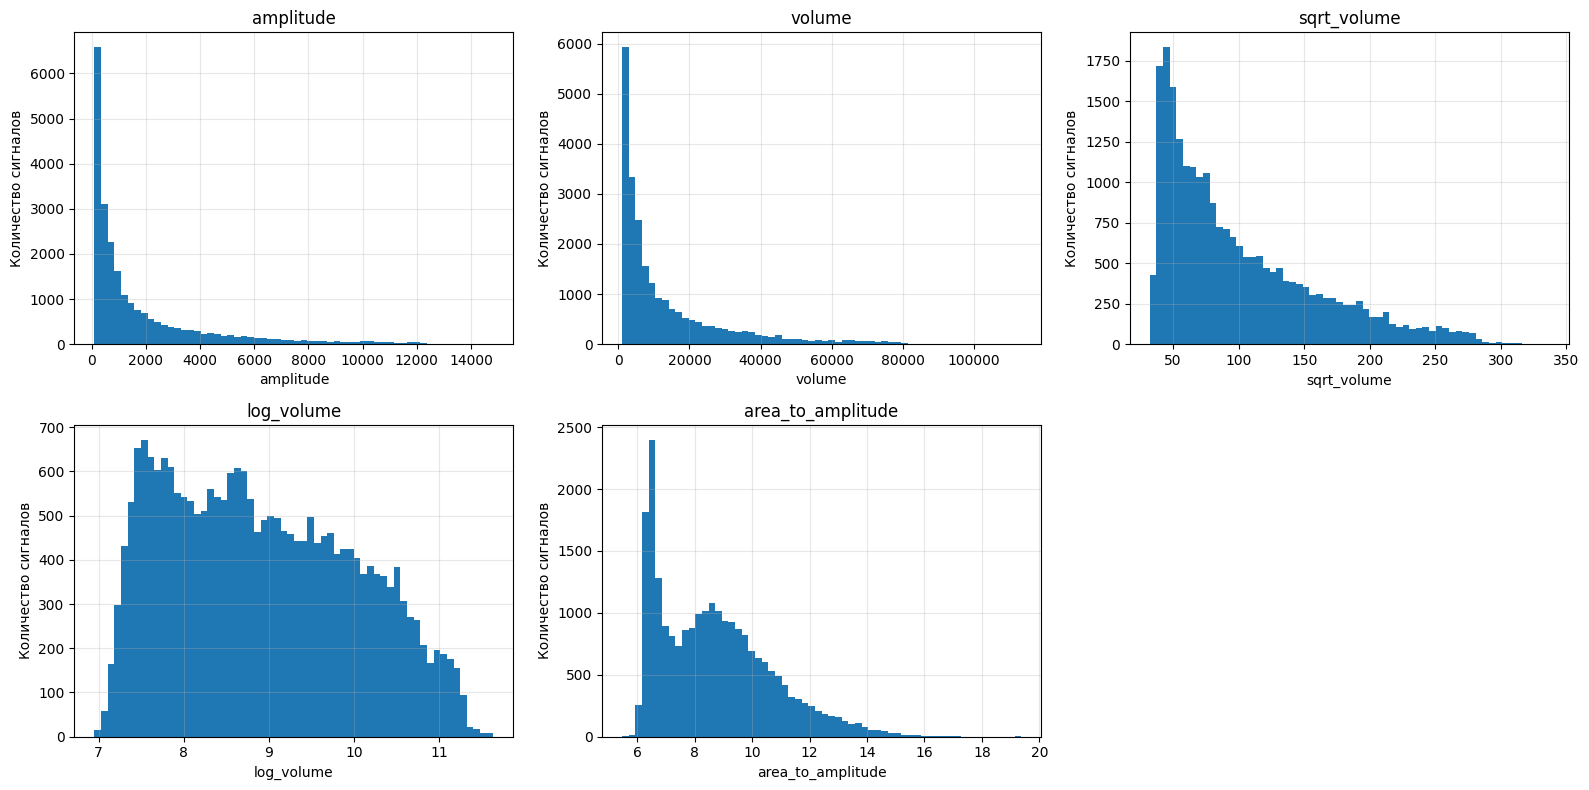

In [ ]:
# Визуализация распределений энергетических признаков
columns_to_plot = [
    "amplitude",
    "volume",
    "sqrt_volume",
    "log_volume",
    "area_to_amplitude",
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 8),
)

axes = axes.ravel()

for axis, column in zip(axes, columns_to_plot):
    axis.hist(engineered_features[column], bins=60)
    axis.set_title(column)
    axis.set_xlabel(column)
    axis.set_ylabel("Количество сигналов")
    axis.grid(alpha=0.3)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

Распределения энергетических признаков показывают сильную правостороннюю асимметрию амплитуды и площади, поэтому преобразования `sqrt_volume` и `log_volume` нужны для более устойчивого представления масштаба импульса перед кластеризацией.

**6.2 Scatter: площадь vs амплитуда**

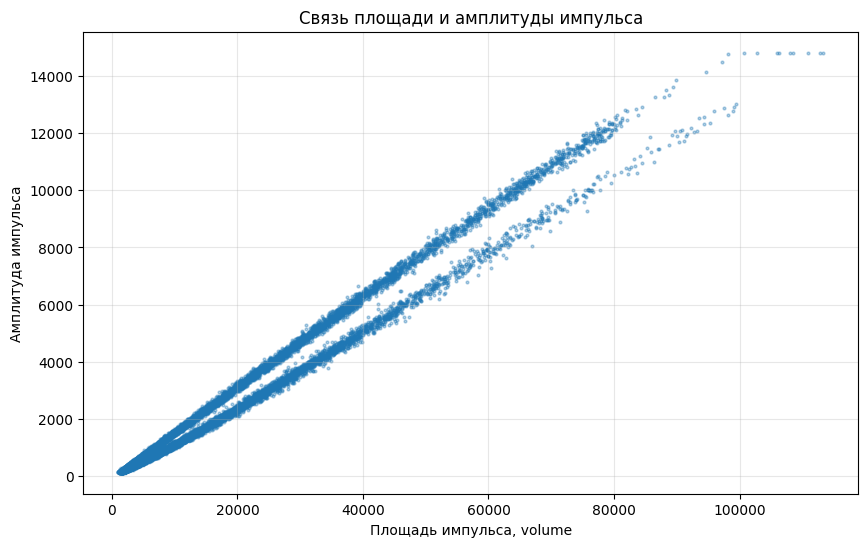

In [ ]:
# Диаграмма рассеяния площади и амплитуды импульса

plt.figure(figsize=(10, 6))

plt.scatter(
    engineered_features["volume"],
    engineered_features["amplitude"],
    s=4,
    alpha=0.35,
)

plt.title("Связь площади и амплитуды импульса")
plt.xlabel("Площадь импульса, volume")
plt.ylabel("Амплитуда импульса")
plt.grid(alpha=0.3)
plt.show()

На scatter-графике `volume`–`amplitude` видны две выраженные ветви сигналов. Это подтверждает, что площадь и амплитуда несут разделяющую информацию, а производные признаки на их основе (`ratio`, `angle`, `area_to_amplitude`) стоит включить в дальнейшие эксперименты.

**6.3 Корреляция физико-интерпретируемых признаков признаков**

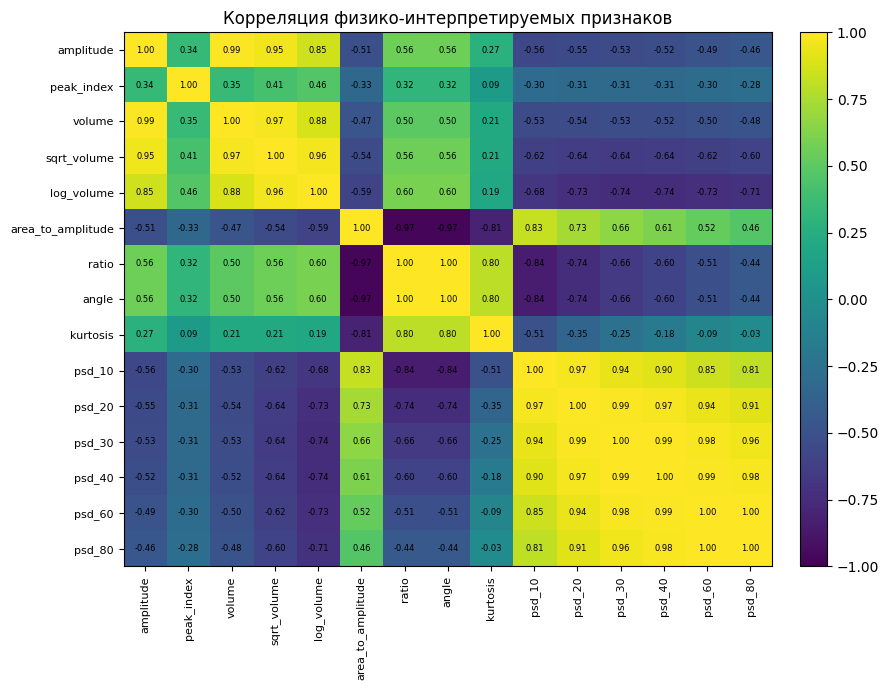

In [ ]:
# Корреляционная матрица признаков в уменьшенном масштабе

corr_matrix = engineered_features.corr()

fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    corr_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1,
)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))

ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.index, fontsize=8)

ax.set_title("Корреляция физико-интерпретируемых признаков", fontsize=12)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6,
        )

plt.tight_layout()
plt.show()

Корреляционная матрица показывает, что часть признаков сильно дублирует друг друга: `amplitude`, `volume`, `sqrt_volume` и `log_volume` описывают общий масштаб импульса, а PSD-признаки с разными окнами также сильно связаны между собой. Поэтому дальше будут проверяться разные наборы признаков, а не только полный набор всех рассчитанных характеристик.

##7. Формирование наборов признаков для экспериментов

In [ ]:
# Формируем несколько наборов физико-интерпретируемых признаков для сравнения моделей

feature_sets = {
    "energy": [
        "amplitude",
        "volume",
        "sqrt_volume",
        "log_volume",
        "area_to_amplitude",
    ],
    "geometry": [
        "sqrt_volume",
        "ratio",
        "angle",
        "kurtosis",
    ],
    "psd": [
        "area_to_amplitude",
        "psd_10",
        "psd_20",
        "psd_30",
        "psd_40",
        "psd_60",
        "psd_80",
    ],
    "geometry_psd": [
        "sqrt_volume",
        "ratio",
        "angle",
        "kurtosis",
        "psd_20",
        "psd_30",
        "psd_40",
    ],
    "all_engineered": list(engineered_features.columns),
}

print("Сформированные наборы признаков:")

for feature_set_name, columns in feature_sets.items():
    print(f"\n{feature_set_name}: {len(columns)} признаков")
    print(columns)

Сформированные наборы признаков:

energy: 5 признаков
['amplitude', 'volume', 'sqrt_volume', 'log_volume', 'area_to_amplitude']

geometry: 4 признаков
['sqrt_volume', 'ratio', 'angle', 'kurtosis']

psd: 7 признаков
['area_to_amplitude', 'psd_10', 'psd_20', 'psd_30', 'psd_40', 'psd_60', 'psd_80']

geometry_psd: 7 признаков
['sqrt_volume', 'ratio', 'angle', 'kurtosis', 'psd_20', 'psd_30', 'psd_40']

all_engineered: 15 признаков
['amplitude', 'peak_index', 'volume', 'sqrt_volume', 'log_volume', 'area_to_amplitude', 'ratio', 'angle', 'kurtosis', 'psd_10', 'psd_20', 'psd_30', 'psd_40', 'psd_60', 'psd_80']


Сформированы пять наборов признаков для экспериментов. Это позволяет отдельно проверить, что лучше работает для кластеризации: признаки мощности импульса, признаки формы, PSD-характеристики или их комбинации. Такой подход важен, потому что простой полный набор всех признаков не всегда даёт лучшее физически осмысленное разбиение.

##8. Подготовка общей таблицы экспериментов

In [ ]:
experiment_results = []

print("Таблица результатов экспериментов создана.")
print(f"Текущее количество записей: {len(experiment_results)}")

Таблица результатов экспериментов создана.
Текущее количество записей: 0


##9. Вспомогательные функции для оценки экспериментов

In [ ]:
def evaluate_clustering(
    features: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
) -> dict:
    """
    Считает внутренние метрики качества кластеризации и размеры кластеров.
    """
    labels = np.asarray(labels)

    cluster_sizes = pd.Series(labels).value_counts().sort_index().to_dict()

    result = {
        "cluster_0_size": cluster_sizes.get(0, 0),
        "cluster_1_size": cluster_sizes.get(1, 0),
        "cluster_2_size": cluster_sizes.get(2, 0),
        "silhouette": silhouette_score(features, labels),
        "calinski_harabasz": calinski_harabasz_score(features, labels),
        "davies_bouldin": davies_bouldin_score(features, labels),
    }

    return result


def add_experiment_result(
    experiment_id: str,
    feature_set: str,
    scaler: str,
    model_name: str,
    params: dict,
    labels: np.ndarray,
    features: pd.DataFrame | np.ndarray,
    comment: str = "",
) -> None:
    """
    Добавляет результат эксперимента в общую таблицу experiment_results.
    """
    metrics = evaluate_clustering(features, labels)

    experiment_results.append(
        {
            "experiment_id": experiment_id,
            "feature_set": feature_set,
            "scaler": scaler,
            "model": model_name,
            "params": params,
            **metrics,
            "kaggle_score": None,
            "comment": comment,
        }
    )


print("Вспомогательные функции для оценки экспериментов готовы.")

Вспомогательные функции для оценки экспериментов готовы.


##10. Первичное сравнение KMeans на разных наборах признаков

**10.1. Фиксированная подвыборка для silhouette score**

In [ ]:
# Фиксированная подвыборка для расчёта silhouette score

SILHOUETTE_SAMPLE_SIZE = 5000

rng = np.random.default_rng(RANDOM_STATE)

silhouette_indices = rng.choice(
    np.arange(len(engineered_features)),
    size=min(SILHOUETTE_SAMPLE_SIZE, len(engineered_features)),
    replace=False,
)

print(f"Размер подвыборки для silhouette: {len(silhouette_indices)}")
print(f"Первые 10 индексов: {silhouette_indices[:10]}")

Размер подвыборки для silhouette: 5000
Первые 10 индексов: [ 9214 12539 15145 13801  3913 11875 19670 21616  9653 11995]


Для ускорения расчётов silhouette score будет считаться на одной фиксированной подвыборке объектов, одинаковой для всех экспериментов. При этом сами модели обучаются и предсказывают кластеры на полном наборе из 23 479 сигналов.

**10.2. Функция оценки экспериментов**

In [ ]:
def evaluate_clustering(
    features: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
) -> dict:
    """
    Считает внутренние метрики качества кластеризации.

    Модели обучаются и предсказывают кластеры на всех данных.
    Calinski-Harabasz и Davies-Bouldin считаются на всех данных.
    Silhouette считается на одной фиксированной подвыборке объектов.
    """
    labels = np.asarray(labels)

    cluster_sizes = pd.Series(labels).value_counts().sort_index().to_dict()

    features_sample = features[silhouette_indices]
    labels_sample = labels[silhouette_indices]

    result = {
        "cluster_0_size": cluster_sizes.get(0, 0),
        "cluster_1_size": cluster_sizes.get(1, 0),
        "cluster_2_size": cluster_sizes.get(2, 0),
        "silhouette": silhouette_score(features_sample, labels_sample),
        "calinski_harabasz": calinski_harabasz_score(features, labels),
        "davies_bouldin": davies_bouldin_score(features, labels),
    }

    return result


print("Функция оценки экспериментов готова.")

Функция оценки экспериментов готова.


**10.3.Первичное сравнение KMeans на разных наборах признаков**

In [ ]:
scalers = {
    "standard": StandardScaler(),
    "robust": RobustScaler(),
}

for feature_set_name, feature_columns in feature_sets.items():
    X = engineered_features[feature_columns]

    for scaler_name, scaler in scalers.items():
        X_scaled = scaler.fit_transform(X)

        model = KMeans(
            n_clusters=3,
            random_state=RANDOM_STATE,
            n_init=50,
        )

        labels = model.fit_predict(X_scaled)

        metrics = evaluate_clustering(X_scaled, labels)

        experiment_results.append(
            {
                "experiment_id": f"kmeans_{feature_set_name}_{scaler_name}",
                "feature_set": feature_set_name,
                "scaler": scaler_name,
                "model": "KMeans",
                "params": {
                    "n_clusters": 3,
                    "n_init": 50,
                    "random_state": RANDOM_STATE,
                },
                **metrics,
                "kaggle_score": None,
                "comment": "Первичное сравнение KMeans на разных наборах признаков.",
            }
        )

results_df = pd.DataFrame(experiment_results)

display(
    results_df.sort_values(
        by=["silhouette", "calinski_harabasz"],
        ascending=[False, False],
    )
)

,experiment_id,feature_set,scaler,model,params,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,kaggle_score,comment
1,kmeans_energy_robust,energy,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",15000,2174,6305,0.507997,42314.313451,0.674776,None,Первичное сравнение KMeans на разных наборах п...
3,kmeans_geometry_robust,geometry,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",10691,7158,5630,0.443633,25050.248932,0.847508,None,Первичное сравнение KMeans на разных наборах п...
2,kmeans_geometry_standard,geometry,standard,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",5572,11036,6871,0.432255,25030.691004,0.909441,None,Первичное сравнение KMeans на разных наборах п...
0,kmeans_energy_standard,energy,standard,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",10447,3488,9544,0.423484,32568.875734,0.813582,None,Первичное сравнение KMeans на разных наборах п...
5,kmeans_psd_robust,psd,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",4856,9964,8659,0.418339,35439.948313,0.806573,None,Первичное сравнение KMeans на разных наборах п...
4,kmeans_psd_standard,psd,standard,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",9933,8660,4886,0.408450,33398.650113,0.831177,None,Первичное сравнение KMeans на разных наборах п...
9,kmeans_all_engineered_robust,all_engineered,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",7433,12048,3998,0.365528,15255.136922,0.945734,None,Первичное сравнение KMeans на разных наборах п...
6,kmeans_geometry_psd_standard,geometry_psd,standard,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",8561,5862,9056,0.336129,19188.637037,1.053720,None,Первичное сравнение KMeans на разных наборах п...
7,kmeans_geometry_psd_robust,geometry_psd,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",7993,5696,9790,0.328968,19637.959147,1.067716,None,Первичное сравнение KMeans на разных наборах п...
8,kmeans_all_engineered_standard,all_engineered,standard,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",6622,11007,5850,0.319364,16197.378059,1.090077,None,Первичное сравнение KMeans на разных наборах п...


**Вывод по первичному сравнению KMeans**

Для KMeans были проверены разные наборы физико-интерпретируемых признаков и два варианта масштабирования: `StandardScaler` и `RobustScaler`.

Лучший результат по silhouette score показал набор `energy` с `RobustScaler`: `silhouette = 0.508`, `Calinski-Harabasz = 42314`, `Davies-Bouldin = 0.675`. Это говорит о том, что базовые энергетические признаки хорошо разделяют данные на компактные группы.

При этом полный набор `all_engineered` оказался хуже базовых наборов признаков. Это подтверждает, что добавление всех признаков сразу не всегда улучшает кластеризацию: часть признаков дублирует друг друга или добавляет шум для KMeans.

На следующем шаге будет проверена модель Gaussian Mixture Model, так как она может лучше описывать вытянутые и перекрывающиеся группы в признаковом пространстве.

##11. Первичное сравнение GMM на разных наборах признаков

In [ ]:
covariance_types = ["full", "tied", "diag", "spherical"]

for feature_set_name, feature_columns in feature_sets.items():
    X = engineered_features[feature_columns]

    for scaler_name, scaler in scalers.items():
        X_scaled = scaler.fit_transform(X)

        for covariance_type in covariance_types:
            model = GaussianMixture(
                n_components=3,
                covariance_type=covariance_type,
                random_state=RANDOM_STATE,
                max_iter=300,
                n_init=5,
            )

            labels = model.fit_predict(X_scaled)

            metrics = evaluate_clustering(X_scaled, labels)

            experiment_results.append(
                {
                    "experiment_id": (
                        f"gmm_{feature_set_name}_"
                        f"{scaler_name}_{covariance_type}"
                    ),
                    "feature_set": feature_set_name,
                    "scaler": scaler_name,
                    "model": "GaussianMixture",
                    "params": {
                        "n_components": 3,
                        "covariance_type": covariance_type,
                        "max_iter": 300,
                        "n_init": 5,
                        "random_state": RANDOM_STATE,
                    },
                    **metrics,
                    "kaggle_score": None,
                    "comment": (
                        "Первичное сравнение GMM на разных наборах "
                        "признаков и типах ковариации."
                    ),
                }
            )

results_df = pd.DataFrame(experiment_results)

display(
    results_df.sort_values(
        by=["silhouette", "calinski_harabasz"],
        ascending=[False, False],
    ).head(20)
)

,experiment_id,feature_set,scaler,model,params,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,kaggle_score,comment
15,gmm_energy_robust_tied,energy,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'tied',...",17176,1035,5268,0.549542,36872.111106,0.585914,None,Первичное сравнение GMM на разных наборах приз...
1,kmeans_energy_robust,energy,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",15000,2174,6305,0.507997,42314.313451,0.674776,None,Первичное сравнение KMeans на разных наборах п...
17,gmm_energy_robust_spherical,energy,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'spheri...",14427,5738,3314,0.465175,39327.716974,0.718488,None,Первичное сравнение GMM на разных наборах приз...
3,kmeans_geometry_robust,geometry,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",10691,7158,5630,0.443633,25050.248932,0.847508,None,Первичное сравнение KMeans на разных наборах п...
25,gmm_geometry_robust_spherical,geometry,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'spheri...",6798,5811,10870,0.441477,24920.865860,0.844632,None,Первичное сравнение GMM на разных наборах приз...
2,kmeans_geometry_standard,geometry,standard,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",5572,11036,6871,0.432255,25030.691004,0.909441,None,Первичное сравнение KMeans на разных наборах п...
23,gmm_geometry_robust_tied,geometry,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'tied',...",3703,10817,8959,0.428959,21664.048966,0.870470,None,Первичное сравнение GMM на разных наборах приз...
0,kmeans_energy_standard,energy,standard,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",10447,3488,9544,0.423484,32568.875734,0.813582,None,Первичное сравнение KMeans на разных наборах п...
5,kmeans_psd_robust,psd,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",4856,9964,8659,0.418339,35439.948313,0.806573,None,Первичное сравнение KMeans на разных наборах п...
13,gmm_energy_standard_spherical,energy,standard,GaussianMixture,"{'n_components': 3, 'covariance_type': 'spheri...",9413,4437,9629,0.415945,31859.154058,0.835850,None,Первичное сравнение GMM на разных наборах приз...


### Вывод по первичному сравнению GMM

На первичном сравнении GMM лучший результат показала комбинация `energy` + `RobustScaler` + `covariance_type="tied"`: она дала максимальный `silhouette` среди текущих экспериментов и минимальный `Davies-Bouldin`.

Это согласуется с гипотезой, что базовые энергетические признаки уже хорошо разделяют сигналы, а GMM с общей ковариационной матрицей лучше описывает вытянутые группы, чем KMeans.

При этом наборы `geometry_psd` и `all_engineered` пока не улучшили качество, что подтверждает необходимость сравнивать разные наборы признаков, а не использовать все рассчитанные признаки сразу.

##12. Первичное сравнение AgglomerativeClustering на разных наборах признаков

In [ ]:
for feature_set_name, feature_columns in feature_sets.items():
    X = engineered_features[feature_columns]

    for scaler_name, scaler in scalers.items():
        X_scaled = scaler.fit_transform(X)

        model = AgglomerativeClustering(
            n_clusters=3,
            linkage="ward",
        )

        labels = model.fit_predict(X_scaled)

        metrics = evaluate_clustering(X_scaled, labels)

        experiment_results.append(
            {
                "experiment_id": f"agglomerative_{feature_set_name}_{scaler_name}",
                "feature_set": feature_set_name,
                "scaler": scaler_name,
                "model": "AgglomerativeClustering",
                "params": {
                    "n_clusters": 3,
                    "linkage": "ward",
                },
                **metrics,
                "kaggle_score": None,
                "comment": (
                    "Первичное сравнение AgglomerativeClustering "
                    "на разных наборах признаков."
                ),
            }
        )

results_df = pd.DataFrame(experiment_results)

display(
    results_df.sort_values(
        by=["silhouette", "calinski_harabasz"],
        ascending=[False, False],
    ).head(25)
)

,experiment_id,feature_set,scaler,model,params,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,kaggle_score,comment
51,agglomerative_energy_robust,energy,robust,AgglomerativeClustering,"{'n_clusters': 3, 'linkage': 'ward'}",17338,5343,798,0.560346,34601.846597,0.570821,None,Первичное сравнение AgglomerativeClustering на...
15,gmm_energy_robust_tied,energy,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'tied',...",17176,1035,5268,0.549542,36872.111106,0.585914,None,Первичное сравнение GMM на разных наборах приз...
1,kmeans_energy_robust,energy,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",15000,2174,6305,0.507997,42314.313451,0.674776,None,Первичное сравнение KMeans на разных наборах п...
50,agglomerative_energy_standard,energy,standard,AgglomerativeClustering,"{'n_clusters': 3, 'linkage': 'ward'}",16685,5331,1463,0.467637,26842.509621,0.663601,None,Первичное сравнение AgglomerativeClustering на...
17,gmm_energy_robust_spherical,energy,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'spheri...",14427,5738,3314,0.465175,39327.716974,0.718488,None,Первичное сравнение GMM на разных наборах приз...
3,kmeans_geometry_robust,geometry,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",10691,7158,5630,0.443633,25050.248932,0.847508,None,Первичное сравнение KMeans на разных наборах п...
25,gmm_geometry_robust_spherical,geometry,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'spheri...",6798,5811,10870,0.441477,24920.865860,0.844632,None,Первичное сравнение GMM на разных наборах приз...
2,kmeans_geometry_standard,geometry,standard,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",5572,11036,6871,0.432255,25030.691004,0.909441,None,Первичное сравнение KMeans на разных наборах п...
23,gmm_geometry_robust_tied,geometry,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'tied',...",3703,10817,8959,0.428959,21664.048966,0.870470,None,Первичное сравнение GMM на разных наборах приз...
53,agglomerative_geometry_robust,geometry,robust,AgglomerativeClustering,"{'n_clusters': 3, 'linkage': 'ward'}",11154,8605,3720,0.425115,21650.539432,0.823029,None,Первичное сравнение AgglomerativeClustering на...


### Вывод по AgglomerativeClustering

AgglomerativeClustering был проверен на тех же наборах признаков и вариантах масштабирования, что и предыдущие модели. По внутренним метрикам он не превзошёл лучшие результаты KMeans и GMM.

Лучшие варианты AgglomerativeClustering оказались на наборах `geometry` и `psd`, однако их значения silhouette ниже, чем у `gmm_energy_robust_tied` и `kmeans_energy_robust`. Поэтому на текущем этапе основными кандидатами для дальнейшего подбора остаются GMM и KMeans.

##13. Сводная таблица лучших первичных экспериментов

In [ ]:
# Компактная таблица лучших экспериментов по каждой модели

results_df = pd.DataFrame(experiment_results)

best_by_model = (
    results_df
    .sort_values(
        by=["silhouette", "calinski_harabasz", "davies_bouldin"],
        ascending=[False, False, True],
    )
    .groupby("model", as_index=False)
    .head(3)
    .reset_index(drop=True)
)

display(
    best_by_model[
        [
            "experiment_id",
            "feature_set",
            "scaler",
            "model",
            "cluster_0_size",
            "cluster_1_size",
            "cluster_2_size",
            "silhouette",
            "calinski_harabasz",
            "davies_bouldin",
            "kaggle_score",
        ]
    ]
)

,experiment_id,feature_set,scaler,model,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,kaggle_score
0,agglomerative_energy_robust,energy,robust,AgglomerativeClustering,17338,5343,798,0.560346,34601.846597,0.570821,None
1,gmm_energy_robust_tied,energy,robust,GaussianMixture,17176,1035,5268,0.549542,36872.111106,0.585914,None
2,kmeans_energy_robust,energy,robust,KMeans,15000,2174,6305,0.507997,42314.313451,0.674776,None
3,agglomerative_energy_standard,energy,standard,AgglomerativeClustering,16685,5331,1463,0.467637,26842.509621,0.663601,None
4,gmm_energy_robust_spherical,energy,robust,GaussianMixture,14427,5738,3314,0.465175,39327.716974,0.718488,None
5,kmeans_geometry_robust,geometry,robust,KMeans,10691,7158,5630,0.443633,25050.248932,0.847508,None
6,gmm_geometry_robust_spherical,geometry,robust,GaussianMixture,6798,5811,10870,0.441477,24920.865860,0.844632,None
7,kmeans_geometry_standard,geometry,standard,KMeans,5572,11036,6871,0.432255,25030.691004,0.909441,None
8,agglomerative_geometry_robust,geometry,robust,AgglomerativeClustering,11154,8605,3720,0.425115,21650.539432,0.823029,None


##14. Функции для анализа кластеров и сохранения submission

In [ ]:
SUBMISSIONS_DIR = PROJECT_DIR / "submissions"
SUBMISSIONS_DIR.mkdir(exist_ok=True)


def get_cluster_profile(
    labels: np.ndarray,
    features: pd.DataFrame,
) -> pd.DataFrame:
    """
    Строит профиль кластеров: размер кластера и средние значения признаков.

    Это нужно, чтобы понять, какие найденные кластеры похожи на основные
    физические типы сигналов, а какие могут быть аномальными или переходными.
    """
    labels = np.asarray(labels)

    profile = features.copy()
    profile["cluster"] = labels

    cluster_profile = (
        profile
        .groupby("cluster")
        .agg(["count", "mean", "median", "std"])
    )

    return cluster_profile




def save_submission(
    labels: np.ndarray,
    filename: str,
) -> Path:
    """
    Сохраняет файл submission в формате Kaggle: index, cluster.
    """
    submission = pd.DataFrame(
        {
            "index": np.arange(len(labels)),
            "cluster": labels.astype(int),
        }
    )

    submission_path = SUBMISSIONS_DIR / filename
    submission.to_csv(submission_path, index=False)

    print(f"Файл сохранён: {submission_path}")
    display(submission.head())
    display(submission["cluster"].value_counts().sort_index())

    return submission_path


print("Функции для анализа кластеров и сохранения submission готовы.")

Функции для анализа кластеров и сохранения submission готовы.


##15. Анализ кластеров лучшей первичной модели

In [ ]:
# Повторно обучаем лучшую первичную модель и смотрим профиль её кластеров

best_feature_set_name = "energy"
best_feature_columns = feature_sets[best_feature_set_name]

X_best = engineered_features[best_feature_columns]

best_scaler = RobustScaler()
X_best_scaled = best_scaler.fit_transform(X_best)

best_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward",
)

best_labels = best_model.fit_predict(X_best_scaled)

best_profile = get_cluster_profile(
    labels=best_labels,
    features=engineered_features[
        [
            "amplitude",
            "volume",
            "sqrt_volume",
            "log_volume",
            "area_to_amplitude",
            "ratio",
            "angle",
            "kurtosis",
            "psd_20",
            "psd_30",
            "psd_40",
            "peak_index",
        ]
    ],
)

display(best_profile)

amplitude                                      volume                \
            count          mean    median          std  count          mean   
cluster                                                                       
0           17338    685.997557    499.93   547.291189  17338   5758.793574   
1            5343   4289.156818   3913.00  1636.294166   5343  30425.272311   
2             798  10370.467544  10215.03  1290.162907    798  68888.470326   

                                sqrt_volume              ...    psd_30  \
           median           std       count        mean  ...    median   
cluster                                                  ...             
0         4354.75   4183.613235       17338   71.243878  ...  0.398054   
1        28067.28  10862.344875        5343  171.779575  ...  0.317082   
2        67578.24   9943.091220         798  261.819890  ...  0.301863   

                  psd_40                               peak_index              \
              std  count      mean    median       std      count        mean   
cluster                                                                         
0        0.082385  17338  0.391631  0.379900  0.081899      17338  149.163802   
1        0.046645   5343  0.302069  0.302553  0.044451       5343  150.874228   
2        0.043911    798  0.290039  0.291400  0.043327        798  151.387218   

                          
        median       std  
cluster                   
0        149.0  2.736351  
1        151.0  0.445343  
2        151.0  0.487420  

[3 rows x 48 columns]

Профиль кластеров показывает, что лучшая по внутренним метрикам модель `agglomerative_energy_robust` разделяет выборку преимущественно по энергетическому масштабу импульса: от слабых сигналов к очень сильным. Малый кластер 2 содержит наиболее мощные импульсы, но его средний `peak_index` остаётся в типичной области около 151-го отсчёта, поэтому интерпретировать его как аномалии только по этому признаку нельзя.

Следовательно, внутренние метрики не гарантируют физически корректного разделения. Перед выбором финального подхода необходимо проверить модели, которые сильнее учитывают форму сигнала и хвост импульса, например GMM и подход с PCA по хвостовой части.

**15.1 Профиль кластеров GMM energy + RobustScaler + tied**


In [ ]:
# Анализируем профиль кластеров для сильного кандидата GMM energy + RobustScaler + tied

gmm_feature_set_name = "energy"
gmm_feature_columns = feature_sets[gmm_feature_set_name]

X_gmm = engineered_features[gmm_feature_columns]

gmm_scaler = RobustScaler()
X_gmm_scaled = gmm_scaler.fit_transform(X_gmm)

gmm_model = GaussianMixture(
    n_components=3,
    covariance_type="tied",
    random_state=RANDOM_STATE,
    max_iter=300,
    n_init=5,
)

gmm_labels = gmm_model.fit_predict(X_gmm_scaled)

gmm_profile = get_cluster_profile(
    labels=gmm_labels,
    features=engineered_features[
        [
            "amplitude",
            "volume",
            "sqrt_volume",
            "log_volume",
            "area_to_amplitude",
            "ratio",
            "angle",
            "kurtosis",
            "psd_20",
            "psd_30",
            "psd_40",
            "peak_index",
        ]
    ],
)

display(gmm_profile)

amplitude                                    volume                \
            count         mean   median          std  count          mean   
cluster                                                                     
0           17176   679.923846   493.12   552.243568  17176   5625.954640   
1            1035  9805.051362  9700.22  1549.626329   1035  66020.695285   
2            5268  4035.653660  3740.28  1517.933363   5268  28932.873147   

                                sqrt_volume              ...    psd_30  \
           median           std       count        mean  ...    median   
cluster                                                  ...             
0         4303.62   3984.492915       17176   70.581963  ...  0.398641   
1        64526.40  10391.905727        1035  256.193396  ...  0.303837   
2        26972.80   9460.197665        5268  167.900711  ...  0.321377   

                  psd_40                               peak_index              \
              std  count      mean    median       std      count        mean   
cluster                                                                         
0        0.083244  17176  0.391808  0.380591  0.082482      17176  149.149162   
1        0.044590   1035  0.291349  0.291798  0.043654       1035  151.357488   
2        0.046545   5268  0.304531  0.305543  0.044094       5268  150.852126   

                          
        median       std  
cluster                   
0        149.0  2.744680  
1        151.0  0.479492  
2        151.0  0.439161  

[3 rows x 48 columns]

Профиль кластеров `gmm_energy_robust_tied` показывает, что модель разделяет сигналы преимущественно по энергетическому масштабу: от слабых импульсов к очень сильным. Малый кластер содержит наиболее мощные сигналы, однако его `peak_index` остаётся в типичной области около 151-го отсчёта, поэтому такой кластер нельзя уверенно интерпретировать как аномальный только по положению импульса.

Этот результат важен: высокая внутренняя метрика не обязательно означает физически корректное разделение на два типа частиц и аномалии. Поэтому перед формированием submission нужно проверить подходы, которые сильнее учитывают форму спада и хвост сигнала, а не только амплитуду и площадь.

### Вывод по energy-моделям

Энергетические модели показали высокие внутренние метрики, однако анализ профилей кластеров показал, что они разделяют сигналы в основном по мощности импульса: от слабых к очень сильным. Такое разделение не гарантирует соответствие физическим типам частиц и классу аномалий, поэтому далее отдельно проверяется подход, основанный на форме хвоста сигнала после пика.

##16. Подготовка хвостов сигналов после пика

Размер матрицы хвостов: (23479, 80)
Минимум: 0.0000
Максимум: 1.0000


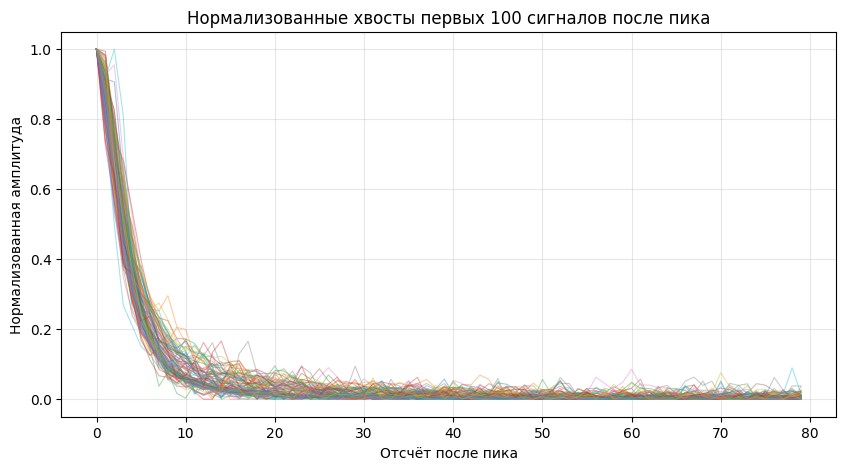

In [ ]:
# Формируем матрицу хвостов после пика для анализа формы спада

TAIL_LENGTH = 80

tail_segments = []

for signal, peak_index in zip(signals_positive, peak_indices):
    start = peak_index
    end = peak_index + TAIL_LENGTH

    if end <= signal.shape[0]:
        tail = signal[start:end]
    else:
        tail = np.zeros(TAIL_LENGTH)
        available_part = signal[start:]
        tail[: len(available_part)] = available_part

    max_value = tail.max()

    if max_value > 0:
        tail = tail / max_value

    tail_segments.append(tail)

tail_segments = np.array(tail_segments)

print(f"Размер матрицы хвостов: {tail_segments.shape}")
print(f"Минимум: {tail_segments.min():.4f}")
print(f"Максимум: {tail_segments.max():.4f}")

plt.figure(figsize=(10, 5))

for index in range(100):
    plt.plot(
        tail_segments[index],
        linewidth=0.8,
        alpha=0.4,
    )

plt.title("Нормализованные хвосты первых 100 сигналов после пика")
plt.xlabel("Отсчёт после пика")
plt.ylabel("Нормализованная амплитуда")
plt.grid(alpha=0.3)
plt.show()

Нормализованные хвосты сигналов показывают различия в форме спада после пика при устранённом влиянии абсолютной амплитуды. Такой вариант признакового описания полезен для проверки гипотезы, что тип частицы связан не только с энергией импульса, но и с характером его затухания.

**16.1 PCA-признаки хвоста сигнала**

In [ ]:
tail_scaler = StandardScaler()
tail_scaled = tail_scaler.fit_transform(tail_segments)

tail_pca = PCA(
    n_components=5,
    random_state=RANDOM_STATE,
)

tail_pca_features = tail_pca.fit_transform(tail_scaled)

tail_pca_columns = [
    f"tail_pca_{component_number}"
    for component_number in range(1, tail_pca_features.shape[1] + 1)
]

tail_pca_features = pd.DataFrame(
    tail_pca_features,
    columns=tail_pca_columns,
)

print(f"Размер PCA-признаков хвоста: {tail_pca_features.shape}")
print("Доля объяснённой дисперсии:")
display(
    pd.Series(
        tail_pca.explained_variance_ratio_,
        index=tail_pca_columns,
    )
)

display(tail_pca_features.head())

Размер PCA-признаков хвоста: (23479, 5)
Доля объяснённой дисперсии:


,0
tail_pca_1,0.391445
tail_pca_2,0.043456
tail_pca_3,0.021659
tail_pca_4,0.015913
tail_pca_5,0.015102


,tail_pca_1,tail_pca_2,tail_pca_3,tail_pca_4,tail_pca_5
0,5.252247,-1.963202,0.864124,0.735665,-3.405769
1,-4.956987,1.882105,0.504879,0.000476,-0.173658
2,-6.636079,-1.061113,-0.946632,-0.186887,-0.106875
3,2.686049,1.222707,0.210802,-1.213209,-0.091418
4,-5.209635,1.377594,0.007607,-0.050093,0.092811


PCA по нормализованным хвостам сигналов показал, что первая компонента объясняет около 39% дисперсии формы спада, а следующие компоненты добавляют существенно меньший вклад. Поэтому хвост сигнала можно рассматривать как отдельное признаковое пространство, но перед выводами о его полезности нужно проверить качество кластеризации на этих PCA-признаках.

**16.2 Кластеризация PCA-признаков хвоста**





In [ ]:
# Проверяем KMeans и GMM на PCA-признаках хвоста

tail_experiment_features = tail_pca_features

tail_models = {
    "KMeans": KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=50,
    ),
    "GMM_tied": GaussianMixture(
        n_components=3,
        covariance_type="tied",
        random_state=RANDOM_STATE,
        max_iter=300,
        n_init=5,
    ),
    "GMM_full": GaussianMixture(
        n_components=3,
        covariance_type="full",
        random_state=RANDOM_STATE,
        max_iter=300,
        n_init=5,
    ),
}

for model_name, model in tail_models.items():
    labels = model.fit_predict(tail_experiment_features)

    metrics = evaluate_clustering(
        tail_experiment_features.to_numpy(),
        labels,
    )

    experiment_results.append(
        {
            "experiment_id": f"tail_pca_80_{model_name.lower()}",
            "feature_set": "tail_pca_80",
            "scaler": "standard",
            "model": model_name,
            "params": {
                "tail_length": TAIL_LENGTH,
                "pca_components": 5,
            },
            **metrics,
            "kaggle_score": None,
            "comment": "Кластеризация формы хвоста после пика с PCA.",
        }
    )

results_df = pd.DataFrame(experiment_results)

display(
    results_df.sort_values(
        by=["silhouette", "calinski_harabasz"],
        ascending=[False, False],
    ).head(20)
)

,experiment_id,feature_set,scaler,model,params,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,kaggle_score,comment
51,agglomerative_energy_robust,energy,robust,AgglomerativeClustering,"{'n_clusters': 3, 'linkage': 'ward'}",17338,5343,798,0.560346,34601.846597,0.570821,None,Первичное сравнение AgglomerativeClustering на...
15,gmm_energy_robust_tied,energy,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'tied',...",17176,1035,5268,0.549542,36872.111106,0.585914,None,Первичное сравнение GMM на разных наборах приз...
1,kmeans_energy_robust,energy,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",15000,2174,6305,0.507997,42314.313451,0.674776,None,Первичное сравнение KMeans на разных наборах п...
50,agglomerative_energy_standard,energy,standard,AgglomerativeClustering,"{'n_clusters': 3, 'linkage': 'ward'}",16685,5331,1463,0.467637,26842.509621,0.663601,None,Первичное сравнение AgglomerativeClustering на...
17,gmm_energy_robust_spherical,energy,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'spheri...",14427,5738,3314,0.465175,39327.716974,0.718488,None,Первичное сравнение GMM на разных наборах приз...
3,kmeans_geometry_robust,geometry,robust,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",10691,7158,5630,0.443633,25050.248932,0.847508,None,Первичное сравнение KMeans на разных наборах п...
25,gmm_geometry_robust_spherical,geometry,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'spheri...",6798,5811,10870,0.441477,24920.865860,0.844632,None,Первичное сравнение GMM на разных наборах приз...
60,tail_pca_80_kmeans,tail_pca_80,standard,KMeans,"{'tail_length': 80, 'pca_components': 5}",11267,7402,4810,0.438567,30899.063305,1.066516,None,Кластеризация формы хвоста после пика с PCA.
2,kmeans_geometry_standard,geometry,standard,KMeans,"{'n_clusters': 3, 'n_init': 50, 'random_state'...",5572,11036,6871,0.432255,25030.691004,0.909441,None,Первичное сравнение KMeans на разных наборах п...
23,gmm_geometry_robust_tied,geometry,robust,GaussianMixture,"{'n_components': 3, 'covariance_type': 'tied',...",3703,10817,8959,0.428959,21664.048966,0.870470,None,Первичное сравнение GMM на разных наборах приз...


### Вывод по кластеризации PCA-признаков хвоста

Кластеризация PCA-признаков хвоста показала результат ниже, чем лучшие модели на энергетических признаках, но сопоставимый с моделями на геометрических признаках. Лучшим вариантом в этой ветке стал `tail_pca_80_kmeans`.

Это означает, что форма хвоста действительно содержит разделяющую информацию, однако в текущей конфигурации `tail_len = 80` и `PCA(n_components=5)` она пока уступает энергетическим признакам по внутренним метрикам. Поэтому ветку хвоста стоит оставить как кандидат для дальнейшего подбора параметров, но не считать её текущим лидером.

**16.3 Профиль кластеров tail PCA + KMeans**

In [ ]:
# Анализируем профиль кластеров для tail_pca_80_kmeans

tail_kmeans_model = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=50,
)

tail_kmeans_labels = tail_kmeans_model.fit_predict(tail_pca_features)

tail_kmeans_profile = get_cluster_profile(
    labels=tail_kmeans_labels,
    features=engineered_features[
        [
            "amplitude",
            "volume",
            "sqrt_volume",
            "log_volume",
            "area_to_amplitude",
            "ratio",
            "angle",
            "kurtosis",
            "psd_20",
            "psd_30",
            "psd_40",
            "peak_index",
        ]
    ],
)

display(tail_kmeans_profile)

amplitude                                    volume                \
            count         mean   median          std  count          mean   
cluster                                                                     
0           11267  2423.646511   988.50  2935.420443  11267  16003.036068   
1            7402  1877.902310  1374.77  1747.780977   7402  15809.303359   
2            4810   390.637314   289.91   286.297145   4810   4169.339173   

                                sqrt_volume              ...    psd_30  \
           median           std       count        mean  ...    median   
cluster                                                  ...             
0         6775.00  19113.638800       11267  107.875124  ...  0.349964   
1        12308.56  13516.291089        7402  114.679442  ...  0.369583   
2         3250.66   2641.638615        4810   61.889946  ...  0.430256   

                  psd_40                               peak_index              \
              std  count      mean    median       std      count        mean   
cluster                                                                         
0        0.090881  11267  0.356063  0.341269  0.090058      11267  149.834117   
1        0.070928   7402  0.358987  0.346850  0.071928       7402  149.984058   
2        0.073033   4810  0.408841  0.404788  0.073817       4810  148.600208   

                          
        median       std  
cluster                   
0        150.0  3.282203  
1        150.0  1.220137  
2        149.0  1.178779  

[3 rows x 48 columns]

По профилю tail_pca_80_kmeans видно, что эта модель уже меньше похожа на простое деление только по энергии: кластеры отличаются не только amplitude и volume, но и PSD-признаками. Например, кластер 2 имеет самую низкую амплитуду и площадь, но более высокий psd_30/psd_40, то есть он может отражать отдельную форму слабых/растянутых сигналов. Поэтому tail_pca_80_kmeans стоит оставить как кандидат для Kaggle-сабмита, хотя по внутренним метрикам он уступает энергетическим моделям.

Подход `tail_pca_80_kmeans` учитывает форму спада сигнала, а не только его мощность. Однако при длине хвоста 80 отсчётов он не дал сильного улучшения: вероятно, в такой хвост попадает слишком много шумовой области после затухания. Поэтому далее будет проверена сетка более коротких хвостов после пика.

##17. Улучшенный подход: короткий хвост сигнала после максимума

После первичной проверки хвоста длиной 80 отсчётов было решено проверить более короткие участки после максимума. Это связано с тем, что различия между типами сигналов должны проявляться в ранней форме спада, а слишком длинный хвост может включать уже в основном шумовую область.

In [ ]:
from sklearn.decomposition import PCA


def extract_tail_segments(
    signals_array: np.ndarray,
    peak_positions: np.ndarray,
    tail_length: int,
) -> np.ndarray:
    """
    Извлекает хвост сигнала после пика и нормализует каждый хвост на максимум.
    """
    tails = []

    for signal, peak_position in zip(signals_array, peak_positions):
        start = peak_position
        end = peak_position + tail_length

        if end <= signal.shape[0]:
            tail = signal[start:end]
        else:
            tail = np.zeros(tail_length)
            available_part = signal[start:]
            tail[: len(available_part)] = available_part

        max_value = tail.max()

        if max_value > 0:
            tail = tail / max_value

        tails.append(tail)

    return np.array(tails)


tail_lengths = [120, 100, 80, 60, 45, 35, 20, 15, 5]

for tail_length in tail_lengths:
    tails = extract_tail_segments(
        signals_array=signals_positive,
        peak_positions=peak_indices,
        tail_length=tail_length,
    )

    tails_scaled = StandardScaler().fit_transform(tails)

    pca = PCA(
        n_components=0.95,
        random_state=RANDOM_STATE,
    )

    tails_pca = pca.fit_transform(tails_scaled)

    model = KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=500,
    )

    labels = model.fit_predict(tails_pca)

    metrics = evaluate_clustering(tails_pca, labels)

    experiment_results.append(
        {
            "experiment_id": f"tail_pca_{tail_length}_kmeans_n500",
            "feature_set": f"tail_pca_{tail_length}",
            "scaler": "standard",
            "model": "KMeans",
            "params": {
                "tail_length": tail_length,
                "pca_components": "0.95 variance",
                "actual_pca_components": tails_pca.shape[1],
                "n_init": 500,
            },
            **metrics,
            "kaggle_score": None,
            "comment": "KMeans на PCA-признаках короткого хвоста после пика.",
        }
    )

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["experiment_id"].str.contains("tail_pca")
    ]
    .sort_values(
        by=["silhouette", "calinski_harabasz"],
        ascending=[False, False],
    )
)

,experiment_id,feature_set,scaler,model,params,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,kaggle_score,comment
60,tail_pca_80_kmeans,tail_pca_80,standard,KMeans,"{'tail_length': 80, 'pca_components': 5}",11267,7402,4810,0.438567,30899.063305,1.066516,None,Кластеризация формы хвоста после пика с PCA.
61,tail_pca_80_gmm_tied,tail_pca_80,standard,GMM_tied,"{'tail_length': 80, 'pca_components': 5}",8632,11784,3063,0.423076,25560.880429,1.252308,None,Кластеризация формы хвоста после пика с PCA.
69,tail_pca_20_kmeans_n500,tail_pca_20,standard,KMeans,"{'tail_length': 20, 'pca_components': '0.95 va...",4003,11476,8000,0.349520,16695.697939,1.311315,None,KMeans на PCA-признаках короткого хвоста после...
71,tail_pca_5_kmeans_n500,tail_pca_5,standard,KMeans,"{'tail_length': 5, 'pca_components': '0.95 var...",5661,7218,10600,0.343370,21684.828754,0.931808,None,KMeans на PCA-признаках короткого хвоста после...
70,tail_pca_15_kmeans_n500,tail_pca_15,standard,KMeans,"{'tail_length': 15, 'pca_components': '0.95 va...",11328,8141,4010,0.335961,16613.193751,1.227139,None,KMeans на PCA-признаках короткого хвоста после...
68,tail_pca_35_kmeans_n500,tail_pca_35,standard,KMeans,"{'tail_length': 35, 'pca_components': '0.95 va...",4469,11510,7500,0.331586,13366.250958,1.645937,None,KMeans на PCA-признаках короткого хвоста после...
67,tail_pca_45_kmeans_n500,tail_pca_45,standard,KMeans,"{'tail_length': 45, 'pca_components': '0.95 va...",7341,11466,4672,0.315949,11232.224851,1.831378,None,KMeans на PCA-признаках короткого хвоста после...
66,tail_pca_60_kmeans_n500,tail_pca_60,standard,KMeans,"{'tail_length': 60, 'pca_components': '0.95 va...",11395,7350,4734,0.292405,8866.389478,2.066621,None,KMeans на PCA-признаках короткого хвоста после...
65,tail_pca_80_kmeans_n500,tail_pca_80,standard,KMeans,"{'tail_length': 80, 'pca_components': '0.95 va...",7400,11266,4813,0.259654,6905.152112,2.294135,None,KMeans на PCA-признаках короткого хвоста после...
64,tail_pca_100_kmeans_n500,tail_pca_100,standard,KMeans,"{'tail_length': 100, 'pca_components': '0.95 v...",4583,7786,11110,0.238900,5669.195448,2.473336,None,KMeans на PCA-признаках короткого хвоста после...


### Вывод по сетке коротких хвостов

Сетка экспериментов по длине хвоста показала, что уменьшение `tail_length` меняет структуру кластеров и внутренние метрики. При этом лучшие значения внутренних метрик не обязательно совпадают с лучшим Kaggle score, что уже было видно на энергетических моделях.

Поэтому короткие хвосты `tail_len = 20`, `15`, `5` и `35` стоит проверить через Kaggle submission: они ближе к гипотезе о том, что различия между типами сигналов проявляются в ранней форме спада после пика.

In [ ]:
# Сохраняем submission для наиболее перспективных коротких хвостов

selected_tail_lengths = [20, 15, 5, 35]

tail_submission_paths = {}

for tail_length in selected_tail_lengths:
    print(f"Готовим submission для tail_length = {tail_length}")

    tails = extract_tail_segments(
        signals_array=signals_positive,
        peak_positions=peak_indices,
        tail_length=tail_length,
    )

    tails_scaled = StandardScaler().fit_transform(tails)

    pca = PCA(
        n_components=0.95,
        random_state=RANDOM_STATE,
    )

    tails_pca = pca.fit_transform(tails_scaled)

    model = KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=500,
    )

    labels = model.fit_predict(tails_pca)

    filename = f"submission_tail_pca_{tail_length}_kmeans_n500.csv"

    tail_submission_paths[tail_length] = save_submission(
        labels=labels,
        filename=filename,
    )

    print("-" * 60)

Готовим submission для tail_length = 20
Файл сохранён: submissions/submission_tail_pca_20_kmeans_n500.csv


,index,cluster
0,0,2
1,1,1
2,2,1
3,3,2
4,4,1


,count
cluster,
0,4003
1,11476
2,8000


------------------------------------------------------------
Готовим submission для tail_length = 15
Файл сохранён: submissions/submission_tail_pca_15_kmeans_n500.csv


,index,cluster
0,0,1
1,1,0
2,2,0
3,3,1
4,4,0


...

,count
cluster,
0,5661
1,7218
2,10600


------------------------------------------------------------
Готовим submission для tail_length = 35
Файл сохранён: submissions/submission_tail_pca_35_kmeans_n500.csv


,index,cluster
0,0,2
1,1,1
2,2,1
3,3,2
4,4,1


,count
cluster,
0,4469
1,11510
2,7500


------------------------------------------------------------


##18. Фиксация Kaggle score для tail-submissions

In [ ]:
# Фиксируем полученные Kaggle scores для отправленных tail-submissions

kaggle_scores = {
    "tail_pca_35_kmeans_n500": 0.59678,
    "tail_pca_20_kmeans_n500": 0.57953,
    "tail_pca_5_kmeans_n500": 0.35176,
    "tail_pca_15_kmeans_n500": 0.13484,
}

for experiment_id, score in kaggle_scores.items():
    mask = results_df["experiment_id"] == experiment_id
    results_df.loc[mask, "kaggle_score"] = score

display(
    results_df[
        results_df["experiment_id"].isin(kaggle_scores.keys())
    ][
        [
            "experiment_id",
            "feature_set",
            "model",
            "cluster_0_size",
            "cluster_1_size",
            "cluster_2_size",
            "silhouette",
            "davies_bouldin",
            "kaggle_score",
        ]
    ].sort_values("kaggle_score", ascending=False)
)

,experiment_id,feature_set,model,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,davies_bouldin,kaggle_score
68,tail_pca_35_kmeans_n500,tail_pca_35,KMeans,4469,11510,7500,0.331586,1.645937,0.59678
69,tail_pca_20_kmeans_n500,tail_pca_20,KMeans,4003,11476,8000,0.349520,1.311315,0.57953
71,tail_pca_5_kmeans_n500,tail_pca_5,KMeans,5661,7218,10600,0.343370,0.931808,0.35176
70,tail_pca_15_kmeans_n500,tail_pca_15,KMeans,11328,8141,4010,0.335961,1.227139,0.13484


##19. Проверка tail PCA без StandardScaler

In [ ]:
# Проверяем tail-подход без StandardScaler перед PCA

selected_tail_lengths = [35, 20, 15, 5]

for tail_length in selected_tail_lengths:
    print(f"Считается tail_length = {tail_length}...")

    tails = extract_tail_segments(
        signals_array=signals_positive,
        peak_positions=peak_indices,
        tail_length=tail_length,
    )

    pca = PCA(
        n_components=0.95,
        random_state=RANDOM_STATE,
    )

    tails_pca = pca.fit_transform(tails)

    print(
        f"tail_length = {tail_length}: "
        f"PCA components = {tails_pca.shape[1]}"
    )

    model = KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=500,
    )

    labels = model.fit_predict(tails_pca)

    metrics = evaluate_clustering(tails_pca, labels)

    experiment_results.append(
        {
            "experiment_id": f"tail_pca_{tail_length}_no_scaler_kmeans_n500",
            "feature_set": f"tail_pca_{tail_length}_no_scaler",
            "scaler": "none",
            "model": "KMeans",
            "params": {
                "tail_length": tail_length,
                "pca_components": "0.95 variance",
                "actual_pca_components": tails_pca.shape[1],
                "n_init": 500,
            },
            **metrics,
            "kaggle_score": None,
            "comment": "KMeans на PCA-признаках хвоста без StandardScaler.",
        }
    )

    print(f"tail_length = {tail_length}: готово")
    print("-" * 60)

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["experiment_id"].str.contains("no_scaler")
    ]
    .sort_values(
        by=["silhouette", "calinski_harabasz"],
        ascending=[False, False],
    )
)

Считается tail_length = 35...
tail_length = 35: PCA components = 14
tail_length = 35: готово
------------------------------------------------------------
Считается tail_length = 20...
tail_length = 20: PCA components = 9
tail_length = 20: готово
------------------------------------------------------------
Считается tail_length = 15...
tail_length = 15: PCA components = 7
tail_length = 15: готово
------------------------------------------------------------
Считается tail_length = 5...
tail_length = 5: PCA components = 3
tail_length = 5: готово
------------------------------------------------------------


,experiment_id,feature_set,scaler,model,params,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,kaggle_score,comment
75,tail_pca_5_no_scaler_kmeans_n500,tail_pca_5_no_scaler,none,KMeans,"{'tail_length': 5, 'pca_components': '0.95 var...",7226,10717,5536,0.356534,23485.026050,0.894694,None,KMeans на PCA-признаках хвоста без StandardSca...
74,tail_pca_15_no_scaler_kmeans_n500,tail_pca_15_no_scaler,none,KMeans,"{'tail_length': 15, 'pca_components': '0.95 va...",10571,5047,7861,0.286222,15817.128181,1.143208,None,KMeans на PCA-признаках хвоста без StandardSca...
73,tail_pca_20_no_scaler_kmeans_n500,tail_pca_20_no_scaler,none,KMeans,"{'tail_length': 20, 'pca_components': '0.95 va...",7835,5222,10422,0.275275,14879.814042,1.192467,None,KMeans на PCA-признаках хвоста без StandardSca...
72,tail_pca_35_no_scaler_kmeans_n500,tail_pca_35_no_scaler,none,KMeans,"{'tail_length': 35, 'pca_components': '0.95 va...",10224,8006,5249,0.263684,13722.311311,1.259711,None,KMeans на PCA-признаках хвоста без StandardSca...


##20. Сохранение submission для tail PCA без StandardScaler

In [ ]:
# Сохраняем submission для tail-подхода без StandardScaler перед PCA

selected_tail_lengths = [35, 20, 15, 5]

tail_no_scaler_submission_paths = {}

for tail_length in selected_tail_lengths:
    print(f"Готовим submission для tail_length = {tail_length} без StandardScaler")

    tails = extract_tail_segments(
        signals_array=signals_positive,
        peak_positions=peak_indices,
        tail_length=tail_length,
    )

    pca = PCA(
        n_components=0.95,
        random_state=RANDOM_STATE,
    )

    tails_pca = pca.fit_transform(tails)

    model = KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=500,
    )

    labels = model.fit_predict(tails_pca)

    filename = f"submission_tail_pca_{tail_length}_no_scaler_kmeans_n500.csv"

    tail_no_scaler_submission_paths[tail_length] = save_submission(
        labels=labels,
        filename=filename,
    )

    print("-" * 60)

Готовим submission для tail_length = 35 без StandardScaler
Файл сохранён: submissions/submission_tail_pca_35_no_scaler_kmeans_n500.csv


,index,cluster
0,0,0
1,1,0
2,2,1
3,3,2
4,4,0


,count
cluster,
0,10224
1,8006
2,5249


------------------------------------------------------------
Готовим submission для tail_length = 20 без StandardScaler
Файл сохранён: submissions/submission_tail_pca_20_no_scaler_kmeans_n500.csv


,index,cluster
0,0,2
1,1,2
2,2,0
3,3,1
4,4,2


...

,count
cluster,
0,10571
1,5047
2,7861


------------------------------------------------------------
Готовим submission для tail_length = 5 без StandardScaler
Файл сохранён: submissions/submission_tail_pca_5_no_scaler_kmeans_n500.csv


,index,cluster
0,0,1
1,1,1
2,2,0
3,3,2
4,4,1


,count
cluster,
0,7226
1,10717
2,5536


------------------------------------------------------------


### Вывод по tail PCA без StandardScaler

Удаление `StandardScaler` перед PCA улучшило результат для `tail_len=35`: public score вырос до `0.65356`. Это подтверждает, что стандартизация отдельных временных отсчётов могла искажать естественную форму спада сигнала. Лучшим текущим направлением становится подход `tail_len=35 → PCA → KMeans`.

##21. Фиксация Kaggle score для tail PCA без StandardScaler

In [ ]:
# Фиксируем Kaggle scores в общей таблице экспериментов

kaggle_scores = {
    "tail_pca_35_no_scaler_kmeans_n500": 0.65356,
    "tail_pca_20_no_scaler_kmeans_n500": 0.05656,
    "tail_pca_15_no_scaler_kmeans_n500": 0.24728,
    # "tail_pca_5_no_scaler_kmeans_n500": ...,  # добавь score, если отправлял
}

for result in experiment_results:
    experiment_id = result["experiment_id"]

    if experiment_id in kaggle_scores:
        result["kaggle_score"] = kaggle_scores[experiment_id]

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["kaggle_score"].notna()
    ][
        [
            "experiment_id",
            "feature_set",
            "scaler",
            "model",
            "cluster_0_size",
            "cluster_1_size",
            "cluster_2_size",
            "silhouette",
            "davies_bouldin",
            "kaggle_score",
        ]
    ].sort_values("kaggle_score", ascending=False)
)

,experiment_id,feature_set,scaler,model,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,davies_bouldin,kaggle_score
72,tail_pca_35_no_scaler_kmeans_n500,tail_pca_35_no_scaler,none,KMeans,10224,8006,5249,0.263684,1.259711,0.65356
74,tail_pca_15_no_scaler_kmeans_n500,tail_pca_15_no_scaler,none,KMeans,10571,5047,7861,0.286222,1.143208,0.24728
73,tail_pca_20_no_scaler_kmeans_n500,tail_pca_20_no_scaler,none,KMeans,7835,5222,10422,0.275275,1.192467,0.05656


##22. Уточнение длины хвоста для варианта без *StandardScaler*

In [ ]:
# Проверяем длины хвоста вокруг текущего лучшего tail_len=35 без StandardScaler

near_best_tail_lengths = [25, 30, 32, 35, 38, 40, 45]

for tail_length in near_best_tail_lengths:
    print(f"Считается tail_length = {tail_length}...")

    tails = extract_tail_segments(
        signals_array=signals_positive,
        peak_positions=peak_indices,
        tail_length=tail_length,
    )

    pca = PCA(
        n_components=0.95,
        random_state=RANDOM_STATE,
    )

    tails_pca = pca.fit_transform(tails)

    model = KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=500,
    )

    labels = model.fit_predict(tails_pca)

    metrics = evaluate_clustering(tails_pca, labels)

    experiment_results.append(
        {
            "experiment_id": f"tail_pca_{tail_length}_no_scaler_kmeans_n500_refined",
            "feature_set": f"tail_pca_{tail_length}_no_scaler",
            "scaler": "none",
            "model": "KMeans",
            "params": {
                "tail_length": tail_length,
                "pca_components": "0.95 variance",
                "actual_pca_components": tails_pca.shape[1],
                "n_init": 500,
            },
            **metrics,
            "kaggle_score": None,
            "comment": "Уточнение длины хвоста вокруг лучшего результата без StandardScaler.",
        }
    )

    print(
        f"tail_length = {tail_length}: "
        f"PCA components = {tails_pca.shape[1]}, готово"
    )
    print("-" * 60)

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["experiment_id"].str.contains("refined")
    ].sort_values(
        by=["silhouette", "calinski_harabasz"],
        ascending=[False, False],
    )
)

Считается tail_length = 25...
tail_length = 25: PCA components = 11, готово
------------------------------------------------------------
Считается tail_length = 30...
tail_length = 30: PCA components = 12, готово
------------------------------------------------------------
Считается tail_length = 32...
tail_length = 32: PCA components = 13, готово
------------------------------------------------------------
Считается tail_length = 35...
tail_length = 35: PCA components = 14, готово
------------------------------------------------------------
Считается tail_length = 38...
tail_length = 38: PCA components = 16, готово
------------------------------------------------------------
Считается tail_length = 40...
tail_length = 40: PCA components = 16, готово
------------------------------------------------------------
Считается tail_length = 45...
tail_length = 45: PCA components = 18, готово
------------------------------------------------------------


,experiment_id,feature_set,scaler,model,params,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,kaggle_score,comment
76,tail_pca_25_no_scaler_kmeans_n500_refined,tail_pca_25_no_scaler,none,KMeans,"{'tail_length': 25, 'pca_components': '0.95 va...",7971,5163,10345,0.270101,14305.192751,1.224008,NaN,Уточнение длины хвоста вокруг лучшего результа...
77,tail_pca_30_no_scaler_kmeans_n500_refined,tail_pca_30_no_scaler,none,KMeans,"{'tail_length': 30, 'pca_components': '0.95 va...",10282,7919,5278,0.266892,14073.855449,1.238692,NaN,Уточнение длины хвоста вокруг лучшего результа...
78,tail_pca_32_no_scaler_kmeans_n500_refined,tail_pca_32_no_scaler,none,KMeans,"{'tail_length': 32, 'pca_components': '0.95 va...",5266,10268,7945,0.265200,13891.384834,1.248632,NaN,Уточнение длины хвоста вокруг лучшего результа...
79,tail_pca_35_no_scaler_kmeans_n500_refined,tail_pca_35_no_scaler,none,KMeans,"{'tail_length': 35, 'pca_components': '0.95 va...",10224,8006,5249,0.263684,13722.311311,1.259711,NaN,Уточнение длины хвоста вокруг лучшего результа...
80,tail_pca_38_no_scaler_kmeans_n500_refined,tail_pca_38_no_scaler,none,KMeans,"{'tail_length': 38, 'pca_components': '0.95 va...",10226,7983,5270,0.260422,13445.494177,1.273780,NaN,Уточнение длины хвоста вокруг лучшего результа...
81,tail_pca_40_no_scaler_kmeans_n500_refined,tail_pca_40_no_scaler,none,KMeans,"{'tail_length': 40, 'pca_components': '0.95 va...",5282,7995,10202,0.260369,13439.402683,1.275399,NaN,Уточнение длины хвоста вокруг лучшего результа...
82,tail_pca_45_no_scaler_kmeans_n500_refined,tail_pca_45_no_scaler,none,KMeans,"{'tail_length': 45, 'pca_components': '0.95 va...",5236,8063,10180,0.258012,13202.894024,1.289684,NaN,Уточнение длины хвоста вокруг лучшего результа...


In [ ]:
# Сохраняем submission для уточнённых длин хвоста без StandardScaler

refined_tail_lengths = [25, 30, 32, 35, 38, 40, 45]

refined_submission_paths = {}

for tail_length in refined_tail_lengths:
    print(f"Готовим submission для tail_length = {tail_length}")

    tails = extract_tail_segments(
        signals_array=signals_positive,
        peak_positions=peak_indices,
        tail_length=tail_length,
    )

    pca = PCA(
        n_components=0.95,
        random_state=RANDOM_STATE,
    )

    tails_pca = pca.fit_transform(tails)

    model = KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=500,
    )

    labels = model.fit_predict(tails_pca)

    filename = f"submission_tail_pca_{tail_length}_no_scaler_kmeans_n500_refined.csv"

    refined_submission_paths[tail_length] = save_submission(
        labels=labels,
        filename=filename,
    )

    print("-" * 60)

Готовим submission для tail_length = 25
Файл сохранён: submissions/submission_tail_pca_25_no_scaler_kmeans_n500_refined.csv


,index,cluster
0,0,2
1,1,2
2,2,0
3,3,1
4,4,2


,count
cluster,
0,7971
1,5163
2,10345


------------------------------------------------------------
Готовим submission для tail_length = 30
Файл сохранён: submissions/submission_tail_pca_30_no_scaler_kmeans_n500_refined.csv


,index,cluster
0,0,0
1,1,0
2,2,1
3,3,2
4,4,0


...

,count
cluster,
0,5282
1,7995
2,10202


------------------------------------------------------------
Готовим submission для tail_length = 45
Файл сохранён: submissions/submission_tail_pca_45_no_scaler_kmeans_n500_refined.csv


,index,cluster
0,0,2
1,1,2
2,2,1
3,3,0
4,4,2


,count
cluster,
0,5236
1,8063
2,10180


------------------------------------------------------------


In [ ]:
kaggle_scores = {
    "tail_pca_35_no_scaler_kmeans_n500": 0.65356,
    "tail_pca_20_no_scaler_kmeans_n500": 0.05656,
    "tail_pca_15_no_scaler_kmeans_n500": 0.24728,
    "tail_pca_5_no_scaler_kmeans_n500": 0.35176,

    "tail_pca_25_no_scaler_kmeans_n500_refined": 0.05409,
    "tail_pca_30_no_scaler_kmeans_n500_refined": 0.64772,
    "tail_pca_32_no_scaler_kmeans_n500_refined": 0.29924,
    "tail_pca_35_no_scaler_kmeans_n500_refined": 0.65356,
    "tail_pca_38_no_scaler_kmeans_n500_refined": 0.65369,
    "tail_pca_40_no_scaler_kmeans_n500_refined": 0.44414,
}

for result in experiment_results:
    experiment_id = result["experiment_id"]

    if experiment_id in kaggle_scores:
        result["kaggle_score"] = kaggle_scores[experiment_id]

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["kaggle_score"].notna()
    ][
        [
            "experiment_id",
            "feature_set",
            "scaler",
            "model",
            "cluster_0_size",
            "cluster_1_size",
            "cluster_2_size",
            "silhouette",
            "davies_bouldin",
            "kaggle_score",
        ]
    ].sort_values("kaggle_score", ascending=False)
)

,experiment_id,feature_set,scaler,model,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,davies_bouldin,kaggle_score
80,tail_pca_38_no_scaler_kmeans_n500_refined,tail_pca_38_no_scaler,none,KMeans,10226,7983,5270,0.260422,1.273780,0.65369
72,tail_pca_35_no_scaler_kmeans_n500,tail_pca_35_no_scaler,none,KMeans,10224,8006,5249,0.263684,1.259711,0.65356
79,tail_pca_35_no_scaler_kmeans_n500_refined,tail_pca_35_no_scaler,none,KMeans,10224,8006,5249,0.263684,1.259711,0.65356
77,tail_pca_30_no_scaler_kmeans_n500_refined,tail_pca_30_no_scaler,none,KMeans,10282,7919,5278,0.266892,1.238692,0.64772
81,tail_pca_40_no_scaler_kmeans_n500_refined,tail_pca_40_no_scaler,none,KMeans,5282,7995,10202,0.260369,1.275399,0.44414
75,tail_pca_5_no_scaler_kmeans_n500,tail_pca_5_no_scaler,none,KMeans,7226,10717,5536,0.356534,0.894694,0.35176
78,tail_pca_32_no_scaler_kmeans_n500_refined,tail_pca_32_no_scaler,none,KMeans,5266,10268,7945,0.265200,1.248632,0.29924
74,tail_pca_15_no_scaler_kmeans_n500,tail_pca_15_no_scaler,none,KMeans,10571,5047,7861,0.286222,1.143208,0.24728
73,tail_pca_20_no_scaler_kmeans_n500,tail_pca_20_no_scaler,none,KMeans,7835,5222,10422,0.275275,1.192467,0.05656
76,tail_pca_25_no_scaler_kmeans_n500_refined,tail_pca_25_no_scaler,none,KMeans,7971,5163,10345,0.270101,1.224008,0.05409


Лучший текущий результат на Kaggle показал подход `tail_pca_38_no_scaler_kmeans_n500_refined` с public score `0.65369`. Близкие результаты также дали `tail_len=35` и `tail_len=30`, что подтверждает важность формы раннего хвоста после пика. При этом внутренние метрики не полностью согласуются с Kaggle score, поэтому дальнейшие эксперименты стоит проводить точечно и только вокруг лучшего tail-подхода.

## 23. Улучшение tail-подхода: хвост без обрезки отрицательных значений

В предыдущих tail-экспериментах хвост извлекался из `signals_positive`, где отрицательные значения после baseline-коррекции были заменены на ноль. Такой вариант удобен для расчёта площади импульса, но для анализа формы хвоста он может быть неудачным: слабые колебания около базовой линии искусственно обрезаются.

Поэтому дальше проверяется другой вариант: хвост после максимума извлекается из `signals_inverted`, то есть из сигнала после baseline-коррекции и инверсии, но без `clip` по нулю. Это сохраняет форму раннего спада и небольшие колебания около базовой линии.

Далее проверяется обновлённый вариант: хвост после максимума берётся из `signals_inverted`, затем каждый хвост нормализуется на собственный максимум, после чего применяются масштабирование, PCA и KMeans.

**Tail PCA + KMeans на `signals_inverted`**

In [ ]:
# Улучшенный tail-подход: хвост берём из signals_inverted, без clip по нулю

def extract_tail_shape_from_inverted(
    signals_array: np.ndarray,
    tail_len: int,
) -> np.ndarray:
    """
    Извлекает участок сигнала после максимума и нормализует его на максимум.

    В отличие от предыдущих экспериментов, здесь используется signals_inverted,
    а не signals_positive, чтобы сохранить реальную форму хвоста около нуля.
    """
    tails = []

    for signal in signals_array:
        peak_index = np.argmax(signal)
        tail = signal[peak_index:peak_index + tail_len]

        if len(tail) < tail_len:
            tail = np.pad(
                tail,
                pad_width=(0, tail_len - len(tail)),
                mode="constant",
            )

        max_value = np.max(tail)

        if max_value > 0:
            tail = tail / max_value

        tails.append(tail)

    return np.array(tails)


tail_len = 15

tails_inverted = extract_tail_shape_from_inverted(
    signals_array=signals_inverted,
    tail_len=tail_len,
)

tails_inverted_scaled = StandardScaler().fit_transform(tails_inverted)

pca = PCA(
    n_components=0.95,
    random_state=RANDOM_STATE,
)

tails_inverted_pca = pca.fit_transform(tails_inverted_scaled)

model = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=500,
)

tail_inverted_labels = model.fit_predict(tails_inverted_pca)

metrics = evaluate_clustering(
    tails_inverted_pca,
    tail_inverted_labels,
)

experiment_results.append(
    {
        "experiment_id": "tail_pca_15_inverted_signal_kmeans_n500",
        "feature_set": "tail_pca_15_inverted_signal",
        "scaler": "standard",
        "model": "KMeans",
        "params": {
            "tail_length": tail_len,
            "pca_components": "0.95 variance",
            "actual_pca_components": tails_inverted_pca.shape[1],
            "n_init": 500,
        },
        **metrics,
        "kaggle_score": None,
        "comment": "Tail PCA KMeans: хвост берётся из signals_inverted без clip по нулю.",
    }
)

print(f"tail_len: {tail_len}")
print(f"Размер матрицы хвостов: {tails_inverted.shape}")
print(f"Размер PCA-признаков: {tails_inverted_pca.shape}")
print(f"Количество PCA-компонент: {tails_inverted_pca.shape[1]}")

print()
print("Размеры кластеров:")
display(
    pd.Series(tail_inverted_labels)
    .value_counts()
    .sort_index()
    .to_frame("cluster_size")
)

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["experiment_id"] == "tail_pca_15_inverted_signal_kmeans_n500"
    ][
        [
            "experiment_id",
            "feature_set",
            "scaler",
            "model",
            "cluster_0_size",
            "cluster_1_size",
            "cluster_2_size",
            "silhouette",
            "calinski_harabasz",
            "davies_bouldin",
            "kaggle_score",
        ]
    ]
)

tail_len: 15
Размер матрицы хвостов: (23479, 15)
Размер PCA-признаков: (23479, 9)
Количество PCA-компонент: 9

Размеры кластеров:


,cluster_size
0,8129
1,11323
2,4027


,experiment_id,feature_set,scaler,model,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,kaggle_score
83,tail_pca_15_inverted_signal_kmeans_n500,tail_pca_15_inverted_signal,standard,KMeans,8129,11323,4027,0.335224,16573.193389,1.22756,NaN


В обновлённом tail-подходе хвост извлекался из `signals_inverted`, то есть без обрезки отрицательных значений около baseline. Для `tail_len = 15` после PCA осталось 9 компонент, а KMeans сформировал три кластера размером 8129, 11323 и 4027 объектов. Такой баланс кластеров выглядит более правдоподобно, чем energy-модели, поэтому этот вариант нужно проверить на Kaggle.

**Сохранение submission для `tail_len = 15`**

In [ ]:
submission_tail_15_inverted_path = save_submission(
    labels=tail_inverted_labels,
    filename="submission_tail_pca_15_inverted_signal_kmeans_n500.csv",
)

Файл сохранён: submissions/submission_tail_pca_15_inverted_signal_kmeans_n500.csv


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


,count
cluster,
0,8129
1,11323
2,4027


In [ ]:
# Фиксируем Kaggle score для лучшего tail-подхода

kaggle_scores = {
    "tail_pca_15_inverted_signal_kmeans_n500": 0.84079,
}

for result in experiment_results:
    experiment_id = result["experiment_id"]

    if experiment_id in kaggle_scores:
        result["kaggle_score"] = kaggle_scores[experiment_id]

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["kaggle_score"].notna()
    ][
        [
            "experiment_id",
            "feature_set",
            "scaler",
            "model",
            "cluster_0_size",
            "cluster_1_size",
            "cluster_2_size",
            "silhouette",
            "davies_bouldin",
            "kaggle_score",
        ]
    ].sort_values("kaggle_score", ascending=False)
)

,experiment_id,feature_set,scaler,model,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,davies_bouldin,kaggle_score
83,tail_pca_15_inverted_signal_kmeans_n500,tail_pca_15_inverted_signal,standard,KMeans,8129,11323,4027,0.335224,1.227560,0.84079
80,tail_pca_38_no_scaler_kmeans_n500_refined,tail_pca_38_no_scaler,none,KMeans,10226,7983,5270,0.260422,1.273780,0.65369
72,tail_pca_35_no_scaler_kmeans_n500,tail_pca_35_no_scaler,none,KMeans,10224,8006,5249,0.263684,1.259711,0.65356
79,tail_pca_35_no_scaler_kmeans_n500_refined,tail_pca_35_no_scaler,none,KMeans,10224,8006,5249,0.263684,1.259711,0.65356
77,tail_pca_30_no_scaler_kmeans_n500_refined,tail_pca_30_no_scaler,none,KMeans,10282,7919,5278,0.266892,1.238692,0.64772
81,tail_pca_40_no_scaler_kmeans_n500_refined,tail_pca_40_no_scaler,none,KMeans,5282,7995,10202,0.260369,1.275399,0.44414
75,tail_pca_5_no_scaler_kmeans_n500,tail_pca_5_no_scaler,none,KMeans,7226,10717,5536,0.356534,0.894694,0.35176
78,tail_pca_32_no_scaler_kmeans_n500_refined,tail_pca_32_no_scaler,none,KMeans,5266,10268,7945,0.265200,1.248632,0.29924
74,tail_pca_15_no_scaler_kmeans_n500,tail_pca_15_no_scaler,none,KMeans,10571,5047,7861,0.286222,1.143208,0.24728
73,tail_pca_20_no_scaler_kmeans_n500,tail_pca_20_no_scaler,none,KMeans,7835,5222,10422,0.275275,1.192467,0.05656


### Вывод по улучшенному tail-подходу

Лучший результат на Kaggle показал подход `tail_pca_15_inverted_signal_kmeans_n500` с public score `0.84079`.

Ключевое отличие от предыдущих tail-экспериментов заключалось в том, что хвост сигнала извлекался из `signals_inverted`, то есть из сигнала после baseline-коррекции и инверсии, но без обрезки отрицательных значений. Это позволило сохранить реальную форму спада около базовой линии.

Таким образом, для расчёта энергетических признаков допустимо использовать `signals_positive`, но для анализа формы хвоста необходимо использовать необрезанный `signals_inverted`. Этот результат подтверждает, что тип сигнала лучше определяется не только амплитудой и площадью, а именно формой раннего спада после пика.

##24. Локальная настройка длины хвоста

После успешной проверки `tail_len = 15` локально проверяются соседние значения длины хвоста. На Kaggle отправляются только несколько ближайших кандидатов, а не все варианты из сетки.

In [ ]:
# Проверяем соседние длины хвоста вокруг лучшего tail_len=15

local_tail_lengths = [10, 12, 13, 14, 15, 16, 17, 18, 20]

for tail_len in local_tail_lengths:
    print(f"Считается tail_len = {tail_len}...")

    tails = extract_tail_shape_from_inverted(
        signals_array=signals_inverted,
        tail_len=tail_len,
    )

    tails_scaled = StandardScaler().fit_transform(tails)

    pca = PCA(
        n_components=0.95,
        random_state=RANDOM_STATE,
    )

    tails_pca = pca.fit_transform(tails_scaled)

    model = KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=500,
    )

    labels = model.fit_predict(tails_pca)

    metrics = evaluate_clustering(
        tails_pca,
        labels,
    )

    experiment_results.append(
        {
            "experiment_id": f"tail_pca_{tail_len}_inverted_signal_kmeans_n500_local",
            "feature_set": f"tail_pca_{tail_len}_inverted_signal",
            "scaler": "standard",
            "model": "KMeans",
            "params": {
                "tail_length": tail_len,
                "pca_components": "0.95 variance",
                "actual_pca_components": tails_pca.shape[1],
                "n_init": 500,
            },
            **metrics,
            "kaggle_score": None,
            "comment": "Локальная проверка длины хвоста вокруг лучшего tail_len=15.",
        }
    )

    print(
        f"tail_len = {tail_len}: "
        f"PCA components = {tails_pca.shape[1]}, готово"
    )
    print("-" * 60)

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["experiment_id"].str.contains("_local")
    ][
        [
            "experiment_id",
            "cluster_0_size",
            "cluster_1_size",
            "cluster_2_size",
            "silhouette",
            "calinski_harabasz",
            "davies_bouldin",
            "kaggle_score",
            "params",
        ]
    ].sort_values(
        by=["silhouette", "calinski_harabasz"],
        ascending=[False, False],
    )
)

Считается tail_len = 10...
tail_len = 10: PCA components = 5, готово
------------------------------------------------------------
Считается tail_len = 12...
tail_len = 12: PCA components = 7, готово
------------------------------------------------------------
Считается tail_len = 13...
tail_len = 13: PCA components = 7, готово
------------------------------------------------------------
Считается tail_len = 14...
tail_len = 14: PCA components = 8, готово
------------------------------------------------------------
Считается tail_len = 15...
tail_len = 15: PCA components = 9, готово
------------------------------------------------------------
Считается tail_len = 16...
tail_len = 16: PCA components = 9, готово
------------------------------------------------------------
Считается tail_len = 17...
tail_len = 17: PCA components = 10, готово
------------------------------------------------------------
Считается tail_len = 18...
tail_len = 18: PCA components = 11, готово
-------------------

,experiment_id,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,kaggle_score,params
92,tail_pca_20_inverted_signal_kmeans_n500_local,7983,11487,4009,0.347159,16541.627877,1.310574,NaN,"{'tail_length': 20, 'pca_components': '0.95 va..."
91,tail_pca_18_inverted_signal_kmeans_n500_local,7946,11434,4099,0.341339,16605.554599,1.282143,NaN,"{'tail_length': 18, 'pca_components': '0.95 va..."
89,tail_pca_16_inverted_signal_kmeans_n500_local,11347,8048,4084,0.340524,16981.353752,1.231956,NaN,"{'tail_length': 16, 'pca_components': '0.95 va..."
90,tail_pca_17_inverted_signal_kmeans_n500_local,11386,7944,4149,0.339557,16790.305482,1.258888,NaN,"{'tail_length': 17, 'pca_components': '0.95 va..."
88,tail_pca_15_inverted_signal_kmeans_n500_local,8129,11323,4027,0.335224,16573.193389,1.227560,NaN,"{'tail_length': 15, 'pca_components': '0.95 va..."
87,tail_pca_14_inverted_signal_kmeans_n500_local,8249,11175,4055,0.331599,16651.054638,1.207496,NaN,"{'tail_length': 14, 'pca_components': '0.95 va..."
86,tail_pca_13_inverted_signal_kmeans_n500_local,4043,8507,10929,0.326780,16716.917787,1.184480,NaN,"{'tail_length': 13, 'pca_components': '0.95 va..."
85,tail_pca_12_inverted_signal_kmeans_n500_local,9246,4467,9766,0.303189,16317.112051,1.182496,NaN,"{'tail_length': 12, 'pca_components': '0.95 va..."
84,tail_pca_10_inverted_signal_kmeans_n500_local,5103,8119,10257,0.302189,17331.491603,1.096341,NaN,"{'tail_length': 10, 'pca_components': '0.95 va..."


In [ ]:
# Сохраняем submission только для ближайших кандидатов вокруг tail_len=15

selected_local_tail_lengths = [16, 17, 18]

local_submission_paths = {}

for tail_len in selected_local_tail_lengths:
    print(f"Готовим submission для tail_len = {tail_len}")

    tails = extract_tail_shape_from_inverted(
        signals_array=signals_inverted,
        tail_len=tail_len,
    )

    tails_scaled = StandardScaler().fit_transform(tails)

    pca = PCA(
        n_components=0.95,
        random_state=RANDOM_STATE,
    )

    tails_pca = pca.fit_transform(tails_scaled)

    model = KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=500,
    )

    labels = model.fit_predict(tails_pca)

    filename = f"submission_tail_pca_{tail_len}_inverted_signal_kmeans_n500_local.csv"

    local_submission_paths[tail_len] = save_submission(
        labels=labels,
        filename=filename,
    )

    print("-" * 60)

Готовим submission для tail_len = 16
Файл сохранён: submissions/submission_tail_pca_16_inverted_signal_kmeans_n500_local.csv


,index,cluster
0,0,1
1,1,0
2,2,0
3,3,1
4,4,0


,count
cluster,
0,11347
1,8048
2,4084


------------------------------------------------------------
Готовим submission для tail_len = 17
Файл сохранён: submissions/submission_tail_pca_17_inverted_signal_kmeans_n500_local.csv


,index,cluster
0,0,1
1,1,0
2,2,0
3,3,1
4,4,0


,count
cluster,
0,11386
1,7944
2,4149


------------------------------------------------------------
Готовим submission для tail_len = 18
Файл сохранён: submissions/submission_tail_pca_18_inverted_signal_kmeans_n500_local.csv


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


,count
cluster,
0,7946
1,11434
2,4099


------------------------------------------------------------


In [ ]:
kaggle_scores = {
    "tail_pca_15_inverted_signal_kmeans_n500": 0.84079,
    "tail_pca_16_inverted_signal_kmeans_n500_local": 0.13237,
    "tail_pca_17_inverted_signal_kmeans_n500_local": 0.12964,
    "tail_pca_18_inverted_signal_kmeans_n500_local": 0.84620,
}

for result in experiment_results:
    experiment_id = result["experiment_id"]

    if experiment_id in kaggle_scores:
        result["kaggle_score"] = kaggle_scores[experiment_id]

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["kaggle_score"].notna()
    ][
        [
            "experiment_id",
            "feature_set",
            "scaler",
            "model",
            "cluster_0_size",
            "cluster_1_size",
            "cluster_2_size",
            "silhouette",
            "davies_bouldin",
            "kaggle_score",
        ]
    ].sort_values("kaggle_score", ascending=False)
)

,experiment_id,feature_set,scaler,model,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,davies_bouldin,kaggle_score
91,tail_pca_18_inverted_signal_kmeans_n500_local,tail_pca_18_inverted_signal,standard,KMeans,7946,11434,4099,0.341339,1.282143,0.84620
83,tail_pca_15_inverted_signal_kmeans_n500,tail_pca_15_inverted_signal,standard,KMeans,8129,11323,4027,0.335224,1.227560,0.84079
80,tail_pca_38_no_scaler_kmeans_n500_refined,tail_pca_38_no_scaler,none,KMeans,10226,7983,5270,0.260422,1.273780,0.65369
79,tail_pca_35_no_scaler_kmeans_n500_refined,tail_pca_35_no_scaler,none,KMeans,10224,8006,5249,0.263684,1.259711,0.65356
72,tail_pca_35_no_scaler_kmeans_n500,tail_pca_35_no_scaler,none,KMeans,10224,8006,5249,0.263684,1.259711,0.65356
77,tail_pca_30_no_scaler_kmeans_n500_refined,tail_pca_30_no_scaler,none,KMeans,10282,7919,5278,0.266892,1.238692,0.64772
81,tail_pca_40_no_scaler_kmeans_n500_refined,tail_pca_40_no_scaler,none,KMeans,5282,7995,10202,0.260369,1.275399,0.44414
75,tail_pca_5_no_scaler_kmeans_n500,tail_pca_5_no_scaler,none,KMeans,7226,10717,5536,0.356534,0.894694,0.35176
78,tail_pca_32_no_scaler_kmeans_n500_refined,tail_pca_32_no_scaler,none,KMeans,5266,10268,7945,0.265200,1.248632,0.29924
74,tail_pca_15_no_scaler_kmeans_n500,tail_pca_15_no_scaler,none,KMeans,10571,5047,7861,0.286222,1.143208,0.24728


### Вывод по локальной настройке длины хвоста

После перехода к хвосту, извлечённому из `signals_inverted`, была выполнена локальная проверка длин хвоста около базового варианта `tail_len = 15`. Лучший результат показал `tail_len = 18`: public score вырос с `0.84079` до `0.84620`.

Это подтверждает, что наиболее информативной является ранняя часть спада после пика. Слишком короткий или слишком длинный хвост ухудшает качество, а оптимальная длина в текущих экспериментах находится около 18 временных отсчётов.

##25. Точечная настройка длины хвоста и PCA

In [ ]:
# Точечная проверка вокруг текущего лучшего решения tail_len=18

tail_lengths_to_check = [18, 19, 20, 21, 22]
pca_variance_to_check = [0.90, 0.92, 0.95, 0.97, 0.99]

for tail_len in tail_lengths_to_check:
    for pca_variance in pca_variance_to_check:
        print(f"Считается tail_len={tail_len}, PCA={pca_variance}...")

        tails = extract_tail_shape_from_inverted(
            signals_array=signals_inverted,
            tail_len=tail_len,
        )

        tails_scaled = StandardScaler().fit_transform(tails)

        pca = PCA(
            n_components=pca_variance,
            random_state=RANDOM_STATE,
        )

        tails_pca = pca.fit_transform(tails_scaled)

        model = KMeans(
            n_clusters=3,
            random_state=RANDOM_STATE,
            n_init=500,
        )

        labels = model.fit_predict(tails_pca)

        metrics = evaluate_clustering(
            tails_pca,
            labels,
        )

        experiment_results.append(
            {
                "experiment_id": (
                    f"tail_pca_{tail_len}_inverted_signal_"
                    f"pca_{str(pca_variance).replace('.', '')}_kmeans_n500"
                ),
                "feature_set": f"tail_pca_{tail_len}_inverted_signal",
                "scaler": "standard",
                "model": "KMeans",
                "params": {
                    "tail_length": tail_len,
                    "pca_components": pca_variance,
                    "actual_pca_components": tails_pca.shape[1],
                    "n_init": 500,
                },
                **metrics,
                "kaggle_score": None,
                "comment": "Точечная проверка tail_len и доли дисперсии PCA вокруг лучшего решения.",
            }
        )

        print(
            f"tail_len={tail_len}, PCA={pca_variance}: "
            f"components={tails_pca.shape[1]}, готово"
        )
        print("-" * 60)

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["experiment_id"].str.contains("inverted_signal_pca")
    ][
        [
            "experiment_id",
            "cluster_0_size",
            "cluster_1_size",
            "cluster_2_size",
            "silhouette",
            "calinski_harabasz",
            "davies_bouldin",
            "params",
        ]
    ].sort_values(
        by=["silhouette", "calinski_harabasz"],
        ascending=[False, False],
    )
)

Считается tail_len=18, PCA=0.9...
tail_len=18, PCA=0.9: components=7, готово
------------------------------------------------------------
Считается tail_len=18, PCA=0.92...
tail_len=18, PCA=0.92: components=8, готово
------------------------------------------------------------
Считается tail_len=18, PCA=0.95...
tail_len=18, PCA=0.95: components=11, готово
------------------------------------------------------------
Считается tail_len=18, PCA=0.97...
tail_len=18, PCA=0.97: components=13, готово
------------------------------------------------------------
Считается tail_len=18, PCA=0.99...
tail_len=18, PCA=0.99: components=15, готово
------------------------------------------------------------
Считается tail_len=19, PCA=0.9...
tail_len=19, PCA=0.9: components=8, готово
------------------------------------------------------------
Считается tail_len=19, PCA=0.92...
tail_len=19, PCA=0.92: components=9, готово
------------------------------------------------------------
Считается tail_len=19

,experiment_id,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,calinski_harabasz,davies_bouldin,params
103,tail_pca_20_inverted_signal_pca_09_kmeans_n500,3999,11489,7991,0.367191,18830.482354,1.220056,"{'tail_length': 20, 'pca_components': 0.9, 'ac..."
113,tail_pca_22_inverted_signal_pca_09_kmeans_n500,4124,11501,7854,0.364438,18520.468962,1.259913,"{'tail_length': 22, 'pca_components': 0.9, 'ac..."
108,tail_pca_21_inverted_signal_pca_09_kmeans_n500,11500,4047,7932,0.362961,18304.450407,1.254947,"{'tail_length': 21, 'pca_components': 0.9, 'ac..."
93,tail_pca_18_inverted_signal_pca_09_kmeans_n500,7952,11434,4093,0.362868,18999.475894,1.187530,"{'tail_length': 18, 'pca_components': 0.9, 'ac..."
98,tail_pca_19_inverted_signal_pca_09_kmeans_n500,7994,11439,4046,0.361498,18514.514058,1.218645,"{'tail_length': 19, 'pca_components': 0.9, 'ac..."
104,tail_pca_20_inverted_signal_pca_092_kmeans_n500,7981,4016,11482,0.360867,18095.869220,1.247714,"{'tail_length': 20, 'pca_components': 0.92, 'a..."
109,tail_pca_21_inverted_signal_pca_092_kmeans_n500,4041,7938,11500,0.357769,17666.389311,1.279443,"{'tail_length': 21, 'pca_components': 0.92, 'a..."
94,tail_pca_18_inverted_signal_pca_092_kmeans_n500,11434,4096,7949,0.356036,18214.461883,1.217236,"{'tail_length': 18, 'pca_components': 0.92, 'a..."
99,tail_pca_19_inverted_signal_pca_092_kmeans_n500,11449,4042,7988,0.355743,17831.726775,1.244846,"{'tail_length': 19, 'pca_components': 0.92, 'a..."
114,tail_pca_22_inverted_signal_pca_092_kmeans_n500,11501,7865,4113,0.354000,17253.271690,1.308611,"{'tail_length': 22, 'pca_components': 0.92, 'a..."


### Проверка уточнённых вариантов на Kaggle

После получения результата `0.84620` для варианта `tail_len = 18`, `PCA(n_components=0.95)` было решено выполнить небольшую локальную проверку вокруг найденного решения.

Так как лучшая модель основана на форме раннего спада после пика, дальнейшие эксперименты ограничены близкими значениями длины хвоста и доли объяснённой дисперсии PCA. Это позволяет не менять общую логику решения, а точечно проверить, можно ли немного улучшить качество.

Для Kaggle были выбраны несколько наиболее осмысленных вариантов:

- `tail_len = 18`, `PCA = 0.90`;
- `tail_len = 19`, `PCA = 0.90`;
- `tail_len = 20`, `PCA = 0.90`;
- `tail_len = 18`, `PCA = 0.92`.

Эти варианты выбраны потому, что они находятся рядом с текущим лучшим решением и показывают сопоставимую структуру кластеров. Эти варианты проверяются как локальная настройка уже найденного tail-подхода. Если улучшения не будет, сохраняется предыдущий лучший вариант; если улучшение будет найдено, финальный пайплайн обновляется только в пределах этой же логики.

In [ ]:
selected_tuned_variants = [
    (18, 0.90),
    (19, 0.90),
    (20, 0.90),
    (18, 0.92),
]

tuned_submission_paths = {}

for tail_len, pca_variance in selected_tuned_variants:
    print(f"Готовим submission: tail_len={tail_len}, PCA={pca_variance}")

    tails = extract_tail_shape_from_inverted(
        signals_array=signals_inverted,
        tail_len=tail_len,
    )

    tails_scaled = StandardScaler().fit_transform(tails)

    pca = PCA(
        n_components=pca_variance,
        random_state=RANDOM_STATE,
    )

    tails_pca = pca.fit_transform(tails_scaled)

    model = KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=500,
    )

    labels = model.fit_predict(tails_pca)

    pca_name = str(pca_variance).replace(".", "")

    filename = (
        f"submission_tail_pca_{tail_len}_inverted_signal_"
        f"pca_{pca_name}_kmeans_n500.csv"
    )

    tuned_submission_paths[(tail_len, pca_variance)] = save_submission(
        labels=labels,
        filename=filename,
    )

    print("-" * 60)

Готовим submission: tail_len=18, PCA=0.9
Файл сохранён: submissions/submission_tail_pca_18_inverted_signal_pca_09_kmeans_n500.csv


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


,count
cluster,
0,7952
1,11434
2,4093


------------------------------------------------------------
Готовим submission: tail_len=19, PCA=0.9
Файл сохранён: submissions/submission_tail_pca_19_inverted_signal_pca_09_kmeans_n500.csv


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


...

,count
cluster,
0,3999
1,11489
2,7991


------------------------------------------------------------
Готовим submission: tail_len=18, PCA=0.92
Файл сохранён: submissions/submission_tail_pca_18_inverted_signal_pca_092_kmeans_n500.csv


,index,cluster
0,0,2
1,1,0
2,2,0
3,3,2
4,4,0


,count
cluster,
0,11434
1,4096
2,7949


------------------------------------------------------------


In [ ]:
kaggle_scores = {
    "tail_pca_15_inverted_signal_kmeans_n500": 0.84079,
    "tail_pca_18_inverted_signal_kmeans_n500_local": 0.84620,

    "tail_pca_18_inverted_signal_pca_09_kmeans_n500": 0.84637,
    "tail_pca_19_inverted_signal_pca_09_kmeans_n500": 0.84807,
    "tail_pca_20_inverted_signal_pca_09_kmeans_n500": 0.57941,
}

for result in experiment_results:
    experiment_id = result["experiment_id"]

    if experiment_id in kaggle_scores:
        result["kaggle_score"] = kaggle_scores[experiment_id]

results_df = pd.DataFrame(experiment_results)

display(
    results_df[
        results_df["kaggle_score"].notna()
    ][
        [
            "experiment_id",
            "feature_set",
            "scaler",
            "model",
            "cluster_0_size",
            "cluster_1_size",
            "cluster_2_size",
            "silhouette",
            "davies_bouldin",
            "kaggle_score",
        ]
    ].sort_values("kaggle_score", ascending=False)
)

,experiment_id,feature_set,scaler,model,cluster_0_size,cluster_1_size,cluster_2_size,silhouette,davies_bouldin,kaggle_score
98,tail_pca_19_inverted_signal_pca_09_kmeans_n500,tail_pca_19_inverted_signal,standard,KMeans,7994,11439,4046,0.361498,1.218645,0.84807
93,tail_pca_18_inverted_signal_pca_09_kmeans_n500,tail_pca_18_inverted_signal,standard,KMeans,7952,11434,4093,0.362868,1.187530,0.84637
91,tail_pca_18_inverted_signal_kmeans_n500_local,tail_pca_18_inverted_signal,standard,KMeans,7946,11434,4099,0.341339,1.282143,0.84620
83,tail_pca_15_inverted_signal_kmeans_n500,tail_pca_15_inverted_signal,standard,KMeans,8129,11323,4027,0.335224,1.227560,0.84079
80,tail_pca_38_no_scaler_kmeans_n500_refined,tail_pca_38_no_scaler,none,KMeans,10226,7983,5270,0.260422,1.273780,0.65369
72,tail_pca_35_no_scaler_kmeans_n500,tail_pca_35_no_scaler,none,KMeans,10224,8006,5249,0.263684,1.259711,0.65356
79,tail_pca_35_no_scaler_kmeans_n500_refined,tail_pca_35_no_scaler,none,KMeans,10224,8006,5249,0.263684,1.259711,0.65356
77,tail_pca_30_no_scaler_kmeans_n500_refined,tail_pca_30_no_scaler,none,KMeans,10282,7919,5278,0.266892,1.238692,0.64772
103,tail_pca_20_inverted_signal_pca_09_kmeans_n500,tail_pca_20_inverted_signal,standard,KMeans,3999,11489,7991,0.367191,1.220056,0.57941
81,tail_pca_40_no_scaler_kmeans_n500_refined,tail_pca_40_no_scaler,none,KMeans,5282,7995,10202,0.260369,1.275399,0.44414


##26. Финальная точечная проверка вокруг лучшего решения

In [ ]:
# Проверяем несколько ближайших вариантов вокруг текущего лучшего решения.
# Это не новая модель, а локальная настройка уже выбранного tail-подхода.

final_check_variants = [
    (19, 0.89),
    (19, 0.91),
    (18, 0.89),
]

final_check_paths = {}

for tail_len, pca_variance in final_check_variants:
    print(f"Готовим submission: tail_len={tail_len}, PCA={pca_variance}")

    tails = extract_tail_shape_from_inverted(
        signals_array=signals_inverted,
        tail_len=tail_len,
    )

    tails_scaled = StandardScaler().fit_transform(tails)

    pca = PCA(
        n_components=pca_variance,
        random_state=RANDOM_STATE,
    )

    tails_pca = pca.fit_transform(tails_scaled)

    model = KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=500,
    )

    labels = model.fit_predict(tails_pca)

    pca_name = str(pca_variance).replace(".", "")

    filename = (
        f"submission_tail_pca_{tail_len}_inverted_signal_"
        f"pca_{pca_name}_kmeans_n500_final_check.csv"
    )

    final_check_paths[(tail_len, pca_variance)] = save_submission(
        labels=labels,
        filename=filename,
    )

    print("-" * 60)

Готовим submission: tail_len=19, PCA=0.89
Файл сохранён: submissions/submission_tail_pca_19_inverted_signal_pca_089_kmeans_n500_final_check.csv


,index,cluster
0,0,2
1,1,1
2,2,1
3,3,2
4,4,1


,count
cluster,
0,4037
1,11440
2,8002


------------------------------------------------------------
Готовим submission: tail_len=19, PCA=0.91
Файл сохранён: submissions/submission_tail_pca_19_inverted_signal_pca_091_kmeans_n500_final_check.csv


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


,count
cluster,
0,7994
1,11439
2,4046


------------------------------------------------------------
Готовим submission: tail_len=18, PCA=0.89
Файл сохранён: submissions/submission_tail_pca_18_inverted_signal_pca_089_kmeans_n500_final_check.csv


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


,count
cluster,
0,7944
1,11433
2,4102


------------------------------------------------------------


## Итоговый вывод по экспериментам

* В этом ноутбуке была проведена базовая подготовка сигналов и серия экспериментов по кластеризации. Сначала для каждого сигнала была рассчитана индивидуальная базовая линия по первым 50 отсчётам, затем сигнал был инвертирован относительно baseline. Далее были сформированы два представления: `signals_positive` для расчёта энергетических признаков и `signals_inverted` для анализа формы сигнала без обрезки значений около нуля.

* На первом этапе были построены физико-интерпретируемые признаки: амплитуда, площадь импульса, преобразования площади, геометрические признаки и PSD-признаки. На этих признаках были проверены KMeans, GMM и AgglomerativeClustering. Несмотря на хорошие внутренние метрики у моделей на энергетических признаках, анализ профилей кластеров показал, что такие модели в основном разделяют сигналы по мощности импульса, а не по форме спада.

* Лучший результат дала модель `KMeans`, обученная не на энергетических признаках, а на PCA-признаках короткого хвоста сигнала после максимума. Это физически обосновано: разные типы частиц отличаются не только амплитудой и площадью, но и формой раннего спада импульса. Поэтому хвост извлекался из `signals_inverted`, без `clip` по нулю, чтобы сохранить реальные колебания около базовой линии.

* Финальный пайплайн:

- хвост длиной `tail_len = 19` после максимума;
- хвост извлекается из `signals_inverted`;
- каждый хвост нормализуется на собственный максимум;
- применяется `StandardScaler`;
- применяется `PCA(n_components=0.90)`;
- кластеризация выполняется через `KMeans(n_clusters=3, n_init=500, random_state=42)`.

* Лучший результат на Kaggle показали два близких варианта: `tail_len = 19, PCA = 0.90` и `tail_len = 19, PCA = 0.91`. Оба дали public score `0.84807`. В качестве финального выбран вариант `PCA = 0.90`, так как он использует более компактное представление хвоста и не ухудшает качество.

* Финальный submission-файл:

`submission_tail_pca_19_inverted_signal_pca_09_kmeans_n500.csv`

Именно этот компактный пайплайн будет вынесен в финальный ноутбук с решением.